# U-MIMIC Tutorial: A Complete Walkthrough

**Unified Mechanistic Inference from Multimodal Imaging and Counts**

This notebook provides a hands-on guide to using the U-MIMIC framework for modeling tumor cell population dynamics and drug response. Each section builds on the previous one, using simulated data to illustrate data structures, usage patterns, and result interpretation.

---

### Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Understanding Cell States & Topology](#2-understanding-cell-states--topology)
3. [Drug Dose-Response & Rate Parameters](#3-drug-dose-response--rate-parameters)
4. [Forward Simulation: ODE (Deterministic)](#4-forward-simulation-ode-deterministic)
5. [Stochastic Simulation: Gillespie SSA](#5-stochastic-simulation-gillespie-ssa)
6. [Moment Equations: Mean + Variance (LNA)](#6-moment-equations-mean--variance-lna)
7. [Observation Models: From Biology to Measurements](#7-observation-models-from-biology-to-measurements)
8. [Data Structures: How U-MIMIC Expects Your Data](#8-data-structures-how-u-mimic-expects-your-data)
9. [Synthetic Data Generation](#9-synthetic-data-generation)
10. [Parameter Inference: Maximum Likelihood (MLE)](#10-parameter-inference-maximum-likelihood-mle)
11. [Parameter Inference: Bayesian (MCMC)](#11-parameter-inference-bayesian-mcmc)
12. [Pharmacokinetics: In Vivo Drug Exposure](#12-pharmacokinetics-in-vivo-drug-exposure)
13. [Transfer Learning: In Vitro → In Vivo](#13-transfer-learning-in-vitro--in-vivo)
14. [High-Level Pipeline: YAML Configuration](#14-high-level-pipeline-yaml-configuration)
15. [Summary & Next Steps](#15-summary--next-steps)

---
## 1. Setup & Imports

First, ensure U-MIMIC is installed. Then import the modules we need.

In [1]:
# Install U-MIMIC if not already installed (uncomment the line below)
# !pip install -e /path/to/U-MIMIC[inference]

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Core dynamics
from umimic.dynamics.states import CellType, ModelTopology, StateVector
from umimic.dynamics.rates import RateSet, EmaxHill, ConstantRate
from umimic.dynamics.ode_system import CellDynamicsODE, build_ode_system
from umimic.dynamics.gillespie import GillespieSimulator
from umimic.dynamics.tau_leaping import TauLeapingSimulator
from umimic.dynamics.moment_equations import MomentODE

# Observations
from umimic.observations.cell_counts import CellCountObservation
from umimic.observations.bli import BLIObservation
from umimic.observations.tumor_volume import TumorVolumeObservation
from umimic.observations.biomarkers import BiomarkerObservation
from umimic.observations.multimodal import MultimodalObservation

# Pharmacokinetics
from umimic.pk.compartment import OneCompartmentPK, TwoCompartmentPK
from umimic.pk.dosing import DosingSchedule, Dose
from umimic.pk.exposure import ExposureProfile
from umimic.pk.luciferin import LuciferinKinetics, TissueAttenuation

# Data handling
from umimic.data.schemas import TimeSeriesData, ExperimentalDataset
from umimic.data.synthetic import SyntheticDataGenerator

# Inference
from umimic.inference.likelihood import ModelLikelihood
from umimic.inference.mle import MLEstimator
from umimic.inference.mcmc import MCMCSampler
from umimic.inference.priors import PriorSpec
from umimic.inference.kalman import ExtendedKalmanFilter
from umimic.inference.diagnostics import summarize_mcmc

# Visualization
from umimic.visualization.style import apply_umimic_style, STATE_COLORS
from umimic.visualization.trajectories import (
    plot_population_trajectories, plot_ensemble, plot_dose_response_trajectories
)
from umimic.visualization.dose_response import plot_rate_dose_response, plot_net_growth_curve
from umimic.visualization.posteriors import plot_posterior_marginals, plot_trace

# Pipeline
from umimic.pipeline.config import ExperimentConfig
from umimic.pipeline.experiment import Experiment
from umimic.pipeline.transfer import TransferLearning

# Types
from umimic.types import SimulationResult, EnsembleResult, MLEResult, MCMCResult, InferenceResult

# Apply consistent styling
apply_umimic_style()

# Reproducibility
rng = np.random.default_rng(42)

print("All imports successful! U-MIMIC is ready.")

All imports successful! U-MIMIC is ready.


---
## 2. Understanding Cell States & Topology

U-MIMIC models tumor cells as populations in distinct **biological states**:

| State | Symbol | Meaning |
|-------|--------|---------|
| Proliferating | **P** | Actively dividing cells |
| Quiescent | **Q** | Alive but non-dividing (dormant) |
| Apoptotic | **A** | Dead / dying cells (accumulating) |
| Resistant | **R** | Therapy-resistant cells |

The **topology** defines which states are active and how they connect.

In [2]:
# --- 2-State Topology: P <-> Q ---
topo_2 = ModelTopology.two_state()
print("=== 2-State Topology ===")
print(f"Active states: {[s.value for s in topo_2.active_states]}")
print(f"Transitions:   {[(s.value, t.value) for s, t in topo_2.transitions]}")
print(f"Number of states: {topo_2.n_states}")
print()

# --- 3-State Topology: P <-> Q, with apoptosis -> A ---
topo_3 = ModelTopology.three_state()
print("=== 3-State Topology ===")
print(f"Active states: {[s.value for s in topo_3.active_states]}")
print(f"Transitions:   {[(s.value, t.value) for s, t in topo_3.transitions]}")
print(f"Division states: {[s.value for s in topo_3.division_states]}")
print(f"Death states:    {[s.value for s in topo_3.death_states]}")
print()

# --- 4-State Topology: Full model with resistance ---
topo_4 = ModelTopology.four_state()
print("=== 4-State Topology ===")
print(f"Active states: {[s.value for s in topo_4.active_states]}")
print(f"Transitions:   {[(s.value, t.value) for s, t in topo_4.transitions]}")
print()

# --- StateVector: representing a snapshot of the population ---
state = StateVector(
    populations={CellType.P: 80, CellType.Q: 15, CellType.A: 5},
    time=24.0
)
print("=== StateVector Example ===")
print(f"Time: {state.time} hours")
print(f"Viable cells (P+Q+R): {state.viable}")
print(f"Total cells (P+Q+A+R): {state.total}")
print(f"As array: {state.as_array()}")

=== 2-State Topology ===
Active states: ['proliferating', 'quiescent']
Transitions:   [('proliferating', 'quiescent'), ('quiescent', 'proliferating')]
Number of states: 2

=== 3-State Topology ===
Active states: ['proliferating', 'quiescent', 'apoptotic']
Transitions:   [('proliferating', 'quiescent'), ('quiescent', 'proliferating')]
Division states: ['proliferating']
Death states:    ['proliferating', 'quiescent']

=== 4-State Topology ===
Active states: ['proliferating', 'quiescent', 'apoptotic', 'resistant']
Transitions:   [('proliferating', 'quiescent'), ('quiescent', 'proliferating'), ('proliferating', 'resistant')]

=== StateVector Example ===
Time: 24.0 hours
Viable cells (P+Q+R): 95
Total cells (P+Q+A+R): 100
As array: [80. 15.  5.  0.]


### Interpretation

- **2-State (P-Q)**: Simplest model — cells are either growing or dormant. Good for quick analyses.
- **3-State (P-Q-A)**: Adds dead cell tracking. Essential when you measure dead cells (e.g., trypan blue).
- **4-State (P-Q-A-R)**: Full model with resistance. Use when studying acquired resistance over long treatments.

**Rule of thumb**: Start with 2-state, add complexity only if your data supports it.

---
## 3. Drug Dose-Response & Rate Parameters

U-MIMIC uses **mechanistic rate parameters** to describe how drugs affect cell behavior:

- **Cytotoxic** drugs: increase the death rate → cells die faster
- **Cytostatic** drugs: decrease the birth rate → cells stop dividing

The dose-response relationship follows the **Hill/Emax equation**:

$$E(C) = E_{max} \cdot \frac{C^n}{EC_{50}^n + C^n}$$

In [3]:
# --- Create a CYTOTOXIC drug rate set ---
# The drug increases cell death (like cisplatin, doxorubicin)
rates_cytotoxic = RateSet.cytotoxic_drug(
    b0=0.04,            # baseline birth rate (per hour) ~ 17h doubling time
    d0=0.01,            # baseline death rate (per hour)
    emax_death=0.05,    # maximum additional death rate from drug
    ec50_death=1.0,     # drug concentration for half-max effect (µM)
    hill_death=1.5      # Hill coefficient (steepness of dose-response)
)

# --- Create a CYTOSTATIC drug rate set ---
# The drug blocks cell division (like palbociclib, CDK4/6 inhibitors)
rates_cytostatic = RateSet.cytostatic_drug(
    b0=0.04,            # baseline birth rate
    d0=0.01,            # baseline death rate
    emax_birth=0.8,     # maximum fractional reduction in birth rate (80%)
    ec50_birth=1.0,     # drug concentration for half-max effect
    hill_birth=1.5      # Hill coefficient
)

# --- Examine rates at different drug concentrations ---
concentrations = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]

print("=== Cytotoxic Drug: Death Rate Increases ===")
print(f"{'[Drug] µM':>10} | {'Birth':>8} | {'Death (P)':>10} | {'Net Growth':>11}")
print("-" * 48)
for c in concentrations:
    b = rates_cytotoxic.birth_rate(c)
    d = rates_cytotoxic.death_rate(CellType.P, c)
    net = rates_cytotoxic.net_growth_rate(c)
    print(f"{c:>10.1f} | {b:>8.4f} | {d:>10.4f} | {net:>+11.4f}")

print()
print("=== Cytostatic Drug: Birth Rate Decreases ===")
print(f"{'[Drug] µM':>10} | {'Birth':>8} | {'Death (P)':>10} | {'Net Growth':>11}")
print("-" * 48)
for c in concentrations:
    b = rates_cytostatic.birth_rate(c)
    d = rates_cytostatic.death_rate(CellType.P, c)
    net = rates_cytostatic.net_growth_rate(c)
    print(f"{c:>10.1f} | {b:>8.4f} | {d:>10.4f} | {net:>+11.4f}")

=== Cytotoxic Drug: Death Rate Increases ===
 [Drug] µM |    Birth |  Death (P) |  Net Growth
------------------------------------------------
       0.0 |   0.0400 |     0.0100 |     +0.0300
       0.5 |   0.0400 |     0.0231 |     +0.0169
       1.0 |   0.0400 |     0.0350 |     +0.0050
       2.0 |   0.0400 |     0.0469 |     -0.0069
       5.0 |   0.0400 |     0.0559 |     -0.0159
      10.0 |   0.0400 |     0.0585 |     -0.0185

=== Cytostatic Drug: Birth Rate Decreases ===
 [Drug] µM |    Birth |  Death (P) |  Net Growth
------------------------------------------------
       0.0 |   0.0400 |     0.0100 |     +0.0300
       0.5 |   0.0316 |     0.0100 |     +0.0216
       1.0 |   0.0240 |     0.0100 |     +0.0140
       2.0 |   0.0164 |     0.0100 |     +0.0064
       5.0 |   0.0106 |     0.0100 |     +0.0006
      10.0 |   0.0090 |     0.0100 |     -0.0010


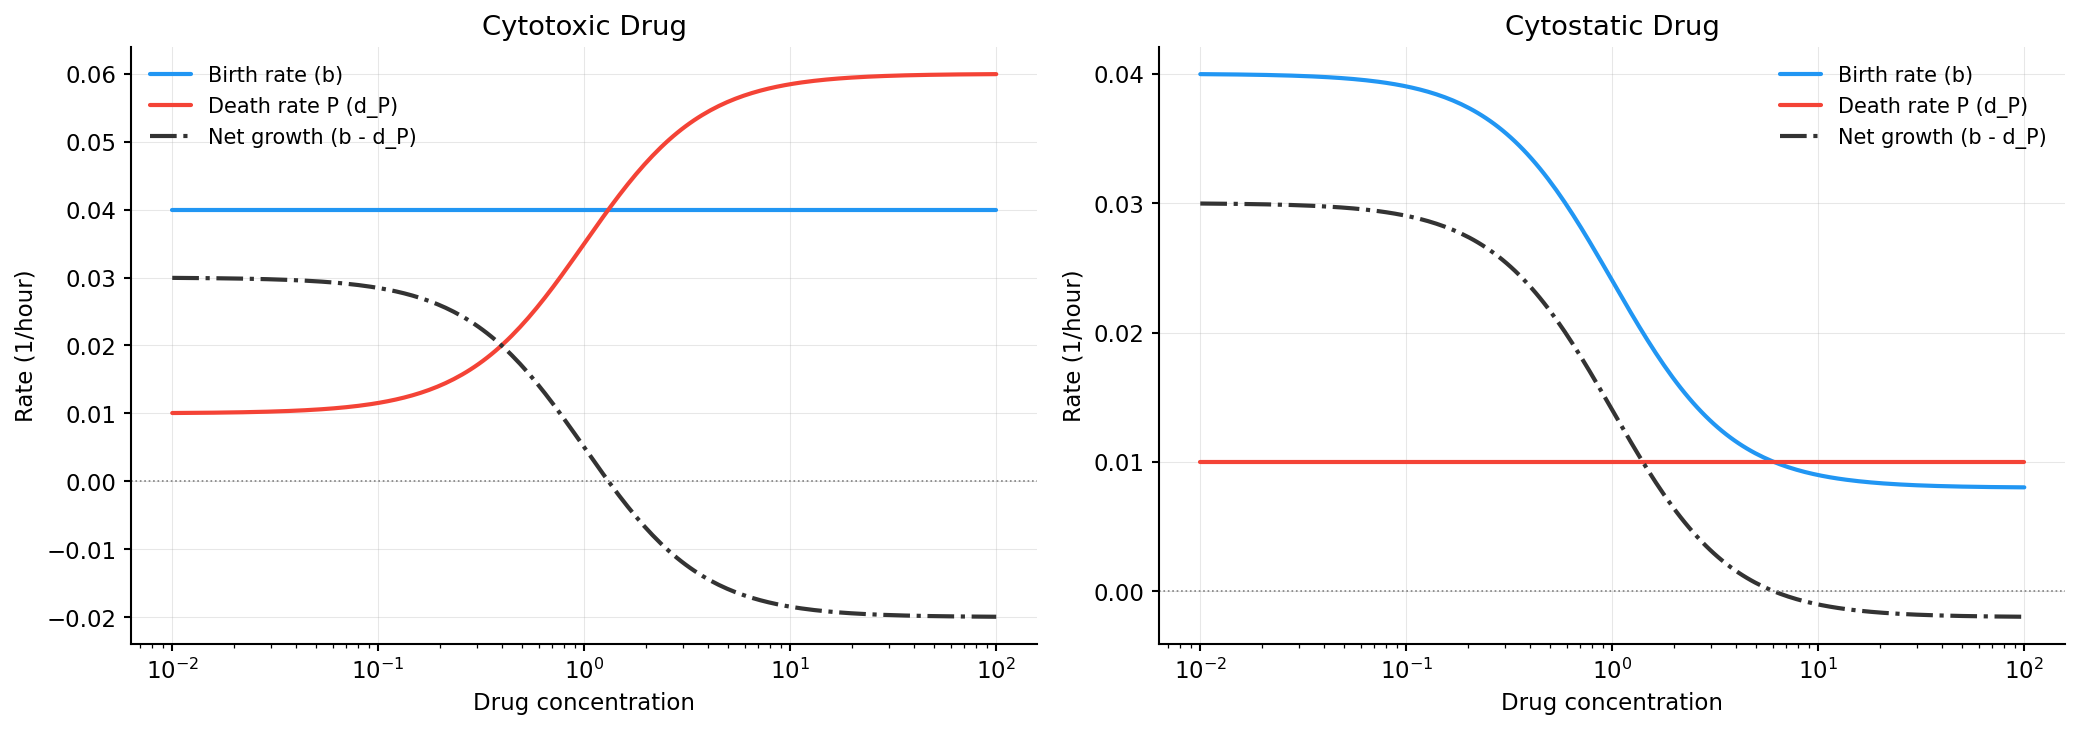

In [4]:
# --- Visualize the dose-response curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_rate_dose_response(rates_cytotoxic, ax=axes[0], title="Cytotoxic Drug")
plot_rate_dose_response(rates_cytostatic, ax=axes[1], title="Cytostatic Drug")

plt.tight_layout()
plt.show()

### Interpretation

| Parameter | Meaning | Typical Range |
|-----------|---------|---------------|
| `b0` | Baseline birth rate (1/h) | 0.02–0.06 (doubling time 12–36h) |
| `d0` | Baseline death rate (1/h) | 0.005–0.02 |
| `emax` | Maximum drug effect | 0.01–0.10 (death), 0.5–0.95 (birth inhibition) |
| `ec50` | Half-maximal concentration | Drug-specific (µM or nM) |
| `hill` | Steepness of response | 1.0–3.0 (1=gradual, 3=switch-like) |

**Net growth rate** = birth − death. When net growth < 0, the population shrinks.

---
## 4. Forward Simulation: ODE (Deterministic)

The simplest simulation method solves the **ordinary differential equations** describing the mean population dynamics. This gives a smooth, deterministic trajectory.

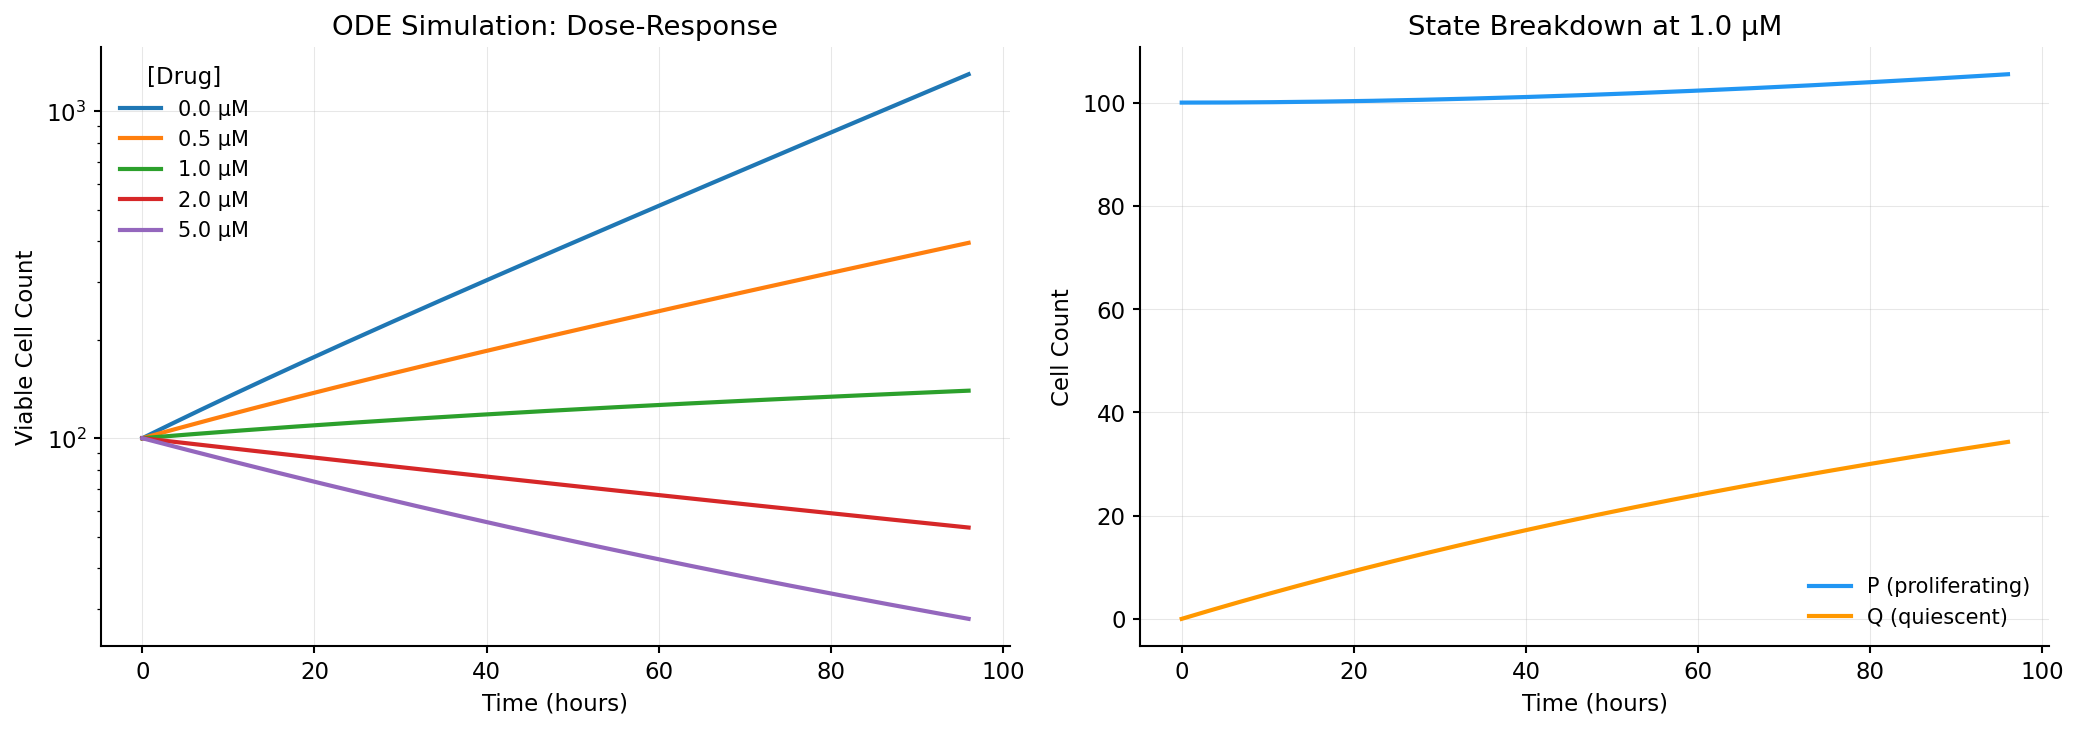


=== SimulationResult Structure ===
Type: SimulationResult
Times shape: (200,)
Available populations: ['P', 'Q']
P population shape: (200,)
Viable at t=0:  100.0 cells
Viable at t=96: 139.8 cells


In [5]:
# --- Setup ---
topology = ModelTopology.two_state()  # P <-> Q
rates = rates_cytotoxic               # cytotoxic drug from above

# Initial conditions: 100 proliferating cells, 0 quiescent
y0 = np.array([100.0, 0.0])  # [P, Q]

# Time settings
t_span = (0, 96)  # 0 to 96 hours (4 days)
t_eval = np.linspace(0, 96, 200)  # fine grid for smooth curves

# --- Simulate at different drug concentrations ---
drug_concs = [0.0, 0.5, 1.0, 2.0, 5.0]
results_ode = {}

for conc in drug_concs:
    # Constant exposure (in vitro plate)
    exposure_fn = lambda t, c=conc: c
    
    # Build and solve the ODE system
    ode = CellDynamicsODE(rate_set=rates, topology=topology, exposure_fn=exposure_fn)
    result = ode.solve(y0=y0, t_span=t_span, t_eval=t_eval)
    results_ode[conc] = result

# --- Plot results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Viable cells (P + Q) across concentrations
for conc, res in results_ode.items():
    axes[0].plot(res.times, res.viable, label=f"{conc} µM", linewidth=2)
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Viable Cell Count")
axes[0].set_title("ODE Simulation: Dose-Response")
axes[0].legend(title="[Drug]")
axes[0].set_yscale("log")

# Right: Individual states for one concentration
res_1um = results_ode[1.0]
axes[1].plot(res_1um.times, res_1um.populations["P"], label="P (proliferating)",
             color=STATE_COLORS["P"], linewidth=2)
axes[1].plot(res_1um.times, res_1um.populations["Q"], label="Q (quiescent)",
             color=STATE_COLORS["Q"], linewidth=2)
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Cell Count")
axes[1].set_title("State Breakdown at 1.0 µM")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Examine the SimulationResult structure ---
print("\n=== SimulationResult Structure ===")
print(f"Type: {type(res_1um).__name__}")
print(f"Times shape: {res_1um.times.shape}")
print(f"Available populations: {list(res_1um.populations.keys())}")
print(f"P population shape: {res_1um.populations['P'].shape}")
print(f"Viable at t=0:  {res_1um.viable[0]:.1f} cells")
print(f"Viable at t=96: {res_1um.viable[-1]:.1f} cells")

### Interpretation

- At **0 µM** (no drug): exponential growth — cells double roughly every ~17 hours.
- At **higher doses**: growth slows and eventually reverses (net growth < 0).
- The **Q state** accumulates over time as some P cells transition to quiescence.
- ODE gives the **mean-field** prediction — no stochastic noise. Good for large populations.

---
## 5. Stochastic Simulation: Gillespie SSA

Real experiments have **noise** — individual cells divide or die at random times. The Gillespie algorithm simulates this stochastic process exactly.

In [6]:
# --- Gillespie simulation at 1.0 µM ---
exposure_fn = lambda t: 1.0  # constant 1 µM

gillespie = GillespieSimulator(
    rate_set=rates_cytotoxic,
    topology=topology,
    exposure_fn=exposure_fn,
    rng=np.random.default_rng(42)
)

# Record observations every 4 hours
t_record = np.arange(0, 97, 4)  # 0, 4, 8, ..., 96

# Run an ensemble of 50 stochastic trajectories
ensemble = gillespie.simulate_ensemble(
    x0=np.array([100, 0]),   # 100 P, 0 Q
    t_max=96.0,
    t_record=t_record,
    n_trajectories=50
)

print("=== EnsembleResult Structure ===")
print(f"Number of trajectories: {ensemble.n_trajectories}")
print(f"Time points: {len(ensemble.times)}")
print(f"Mean P at t=48h: {ensemble.mean()['P'][12]:.1f} cells")
print(f"Std  P at t=48h: {ensemble.std()['P'][12]:.1f} cells")

=== EnsembleResult Structure ===
Number of trajectories: 50
Time points: 25
Mean P at t=48h: 100.7 cells
Std  P at t=48h: 19.4 cells


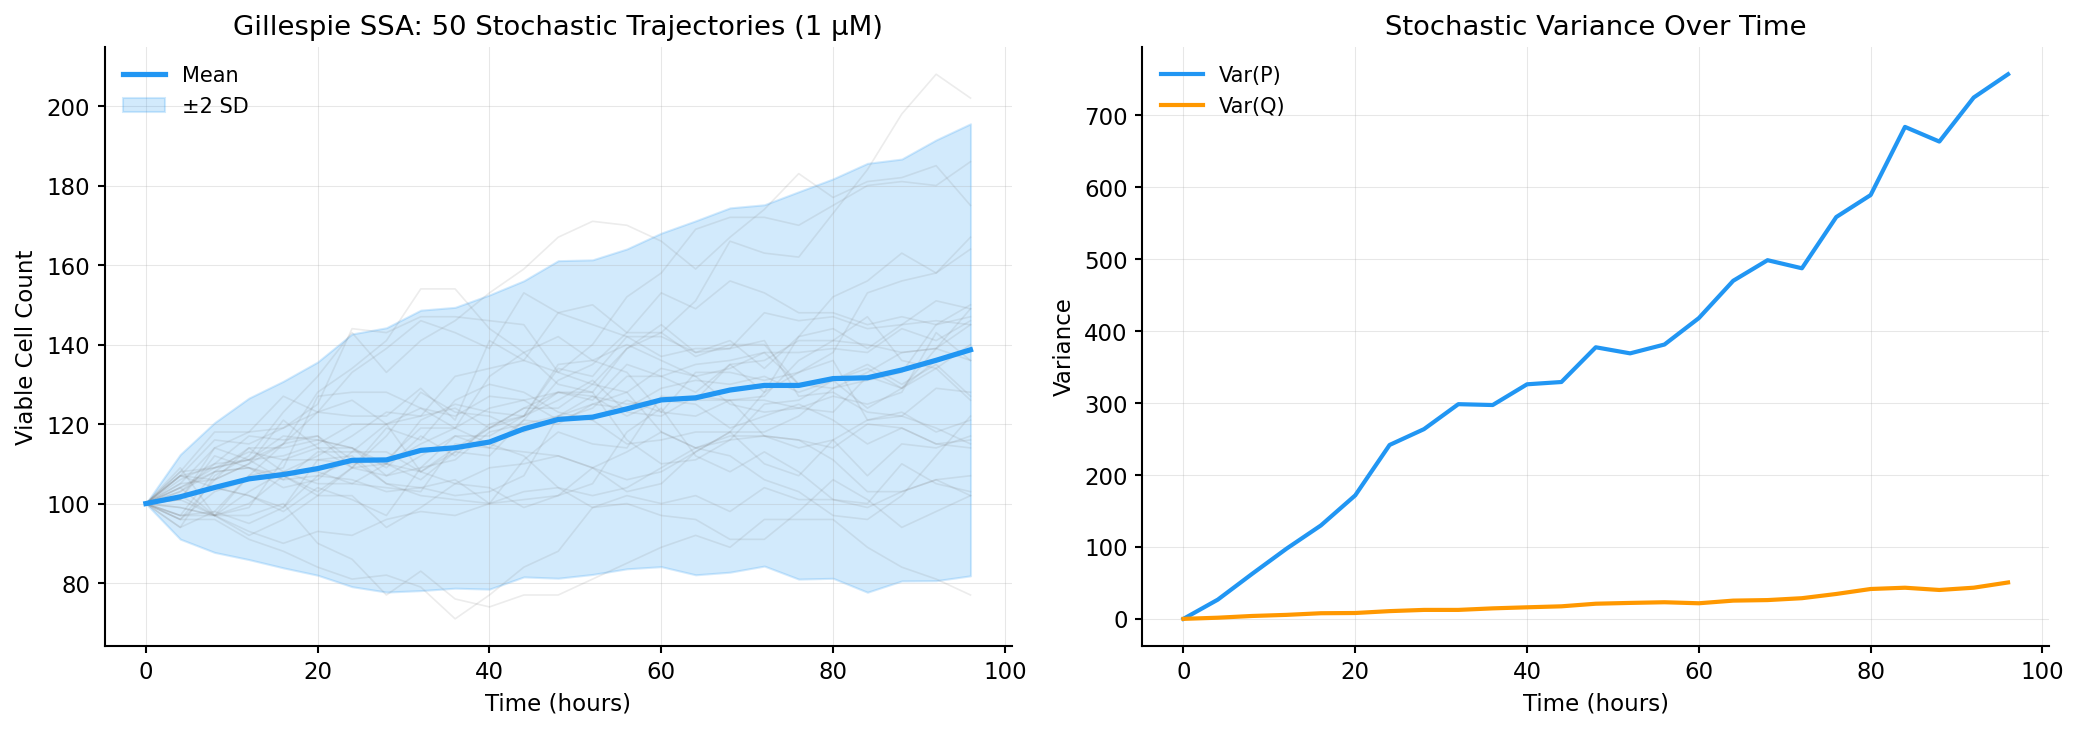

In [7]:
# --- Visualize stochastic trajectories ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Individual trajectories (gray) with mean (blue)
for traj in ensemble.trajectories[:30]:
    viable = traj["P"] + traj["Q"]
    axes[0].plot(ensemble.times, viable, color="gray", alpha=0.15, linewidth=0.8)

mean_viable = ensemble.mean()["P"] + ensemble.mean()["Q"]
std_viable = np.sqrt(ensemble.variance()["P"] + ensemble.variance()["Q"])
axes[0].plot(ensemble.times, mean_viable, color="#2196F3", linewidth=2.5, label="Mean")
axes[0].fill_between(ensemble.times,
                     mean_viable - 2*std_viable,
                     mean_viable + 2*std_viable,
                     alpha=0.2, color="#2196F3", label="±2 SD")
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Viable Cell Count")
axes[0].set_title("Gillespie SSA: 50 Stochastic Trajectories (1 µM)")
axes[0].legend()

# Right: Variance over time — key signature
axes[1].plot(ensemble.times, ensemble.variance()["P"], label="Var(P)",
             color=STATE_COLORS["P"], linewidth=2)
axes[1].plot(ensemble.times, ensemble.variance()["Q"], label="Var(Q)",
             color=STATE_COLORS["Q"], linewidth=2)
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Variance")
axes[1].set_title("Stochastic Variance Over Time")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

- Each gray line is a **single realization** — one possible experimental outcome.
- The blue band shows ±2 standard deviations, capturing ~95% of trajectories.
- **Variance grows over time** because stochastic birth/death events compound.
- With only 100 starting cells, noise is substantial. With 10,000+ cells, trajectories would cluster tightly around the ODE mean.

**Key insight**: The *magnitude* of variance carries information about whether a drug is cytotoxic or cytostatic — this is the **mechanistic variance signature** that U-MIMIC exploits.

---
## 6. Moment Equations: Mean + Variance (LNA)

The **Linear Noise Approximation** propagates both the mean μ(t) and covariance Σ(t) without running many stochastic simulations. This is much faster and provides analytical access to variance.

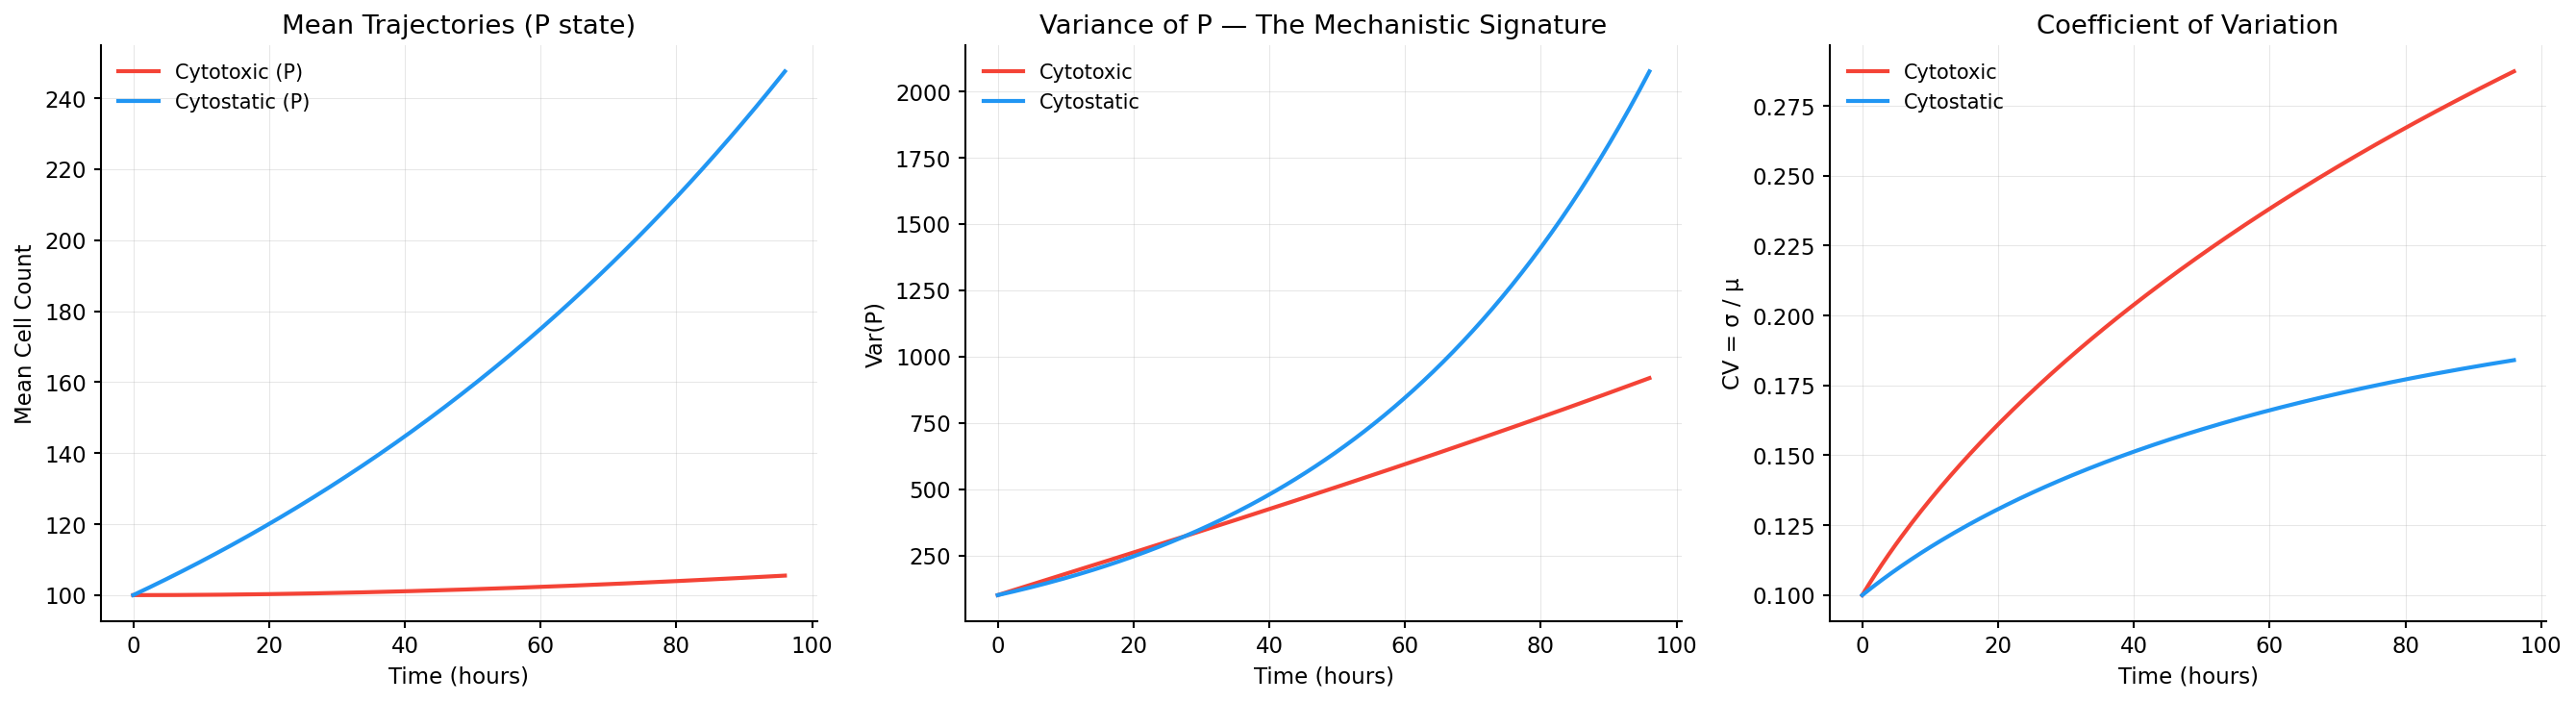


=== LNA Output Structure ===
Times shape: (200,)
Means shape: (200, 2)  (n_times × n_states)
Covs shape:  (200, 2, 2)  (n_times × n_states × n_states)

Variance at t=72h:
  Cytotoxic  Var(P) = 702.3
  Cytostatic Var(P) = 1165.8


In [8]:
# --- Moment ODE for cytotoxic vs. cytostatic comparison ---
exposure_1um = lambda t: 1.0
mu0 = np.array([100.0, 0.0])  # initial mean: [P, Q]
t_eval_fine = np.linspace(0, 96, 200)

# Cytotoxic
moment_cytotoxic = MomentODE(rates_cytotoxic, topology, exposure_1um)
times_ct, means_ct, covs_ct = moment_cytotoxic.solve(
    mu0=mu0, t_span=(0, 96), t_eval=t_eval_fine
)

# Cytostatic
moment_cytostatic = MomentODE(rates_cytostatic, topology, exposure_1um)
times_cs, means_cs, covs_cs = moment_cytostatic.solve(
    mu0=mu0, t_span=(0, 96), t_eval=t_eval_fine
)

# --- Compare ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean trajectories
axes[0].plot(times_ct, means_ct[:, 0], label="Cytotoxic (P)", color="#F44336", linewidth=2)
axes[0].plot(times_cs, means_cs[:, 0], label="Cytostatic (P)", color="#2196F3", linewidth=2)
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Mean Cell Count")
axes[0].set_title("Mean Trajectories (P state)")
axes[0].legend()

# Variance of P
var_P_ct = covs_ct[:, 0, 0]  # Var(P) for cytotoxic
var_P_cs = covs_cs[:, 0, 0]  # Var(P) for cytostatic
axes[1].plot(times_ct, var_P_ct, label="Cytotoxic", color="#F44336", linewidth=2)
axes[1].plot(times_cs, var_P_cs, label="Cytostatic", color="#2196F3", linewidth=2)
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Var(P)")
axes[1].set_title("Variance of P — The Mechanistic Signature")
axes[1].legend()

# Coefficient of variation = std/mean
cv_ct = np.sqrt(var_P_ct) / np.maximum(means_ct[:, 0], 1)
cv_cs = np.sqrt(var_P_cs) / np.maximum(means_cs[:, 0], 1)
axes[2].plot(times_ct, cv_ct, label="Cytotoxic", color="#F44336", linewidth=2)
axes[2].plot(times_cs, cv_cs, label="Cytostatic", color="#2196F3", linewidth=2)
axes[2].set_xlabel("Time (hours)")
axes[2].set_ylabel("CV = σ / μ")
axes[2].set_title("Coefficient of Variation")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n=== LNA Output Structure ===")
print(f"Times shape: {times_ct.shape}")
print(f"Means shape: {means_ct.shape}  (n_times × n_states)")
print(f"Covs shape:  {covs_ct.shape}  (n_times × n_states × n_states)")
print(f"\nVariance at t=72h:")
print(f"  Cytotoxic  Var(P) = {covs_ct[150, 0, 0]:.1f}")
print(f"  Cytostatic Var(P) = {covs_cs[150, 0, 0]:.1f}")

### Interpretation

This is a **key innovation** of U-MIMIC:

- **Cytotoxic** drugs (high birth + high death) produce **large variance** — many births AND deaths = high "turnover".
- **Cytostatic** drugs (low birth + low death) produce **small variance** — few events happen, so less noise.
- Even if the *mean* trajectories look similar, the **variance differs** — this allows U-MIMIC to distinguish drug mechanisms from cell count data alone.

The LNA is computationally efficient (single ODE solve vs. thousands of Gillespie runs).

---
## 7. Observation Models: From Biology to Measurements

Real experiments don't observe the true cell state directly. Each measurement modality has its own **noise model**.

In [9]:
# --- True latent state: 500 P cells, 100 Q cells ---
true_state = np.array([500.0, 100.0])  # [P, Q]

print("True latent state: P=500, Q=100")
print(f"True viable count: {sum(true_state)}\n")

# -------------------------------------------------------
# 7a. Cell Count Observation (Negative Binomial)
# -------------------------------------------------------
obs_counts = CellCountObservation(overdispersion=10.0, count_type="viable")

# Generate 20 simulated measurements
count_samples = [obs_counts.sample(true_state, rng) for _ in range(20)]
print("=== Cell Count Observations ===")
print(f"Expected value: {obs_counts.expected_value(true_state):.0f}")
print(f"20 samples: {[f'{s:.0f}' for s in count_samples]}")
print(f"Sample mean: {np.mean(count_samples):.1f}, Sample std: {np.std(count_samples):.1f}")
print(f"Log-likelihood of observing 580: {obs_counts.log_likelihood(580, true_state):.2f}")
print(f"Log-likelihood of observing 200: {obs_counts.log_likelihood(200, true_state):.2f}  (unlikely!)")

print()

# -------------------------------------------------------
# 7b. BLI Observation (Bioluminescence)
# -------------------------------------------------------
obs_bli = BLIObservation(alpha=1000.0, sigma_log=0.3)
bli_samples = [obs_bli.sample(true_state, rng) for _ in range(20)]
print("=== BLI Observations ===")
print(f"Expected BLI signal: {obs_bli.expected_value(true_state):.0f} photons/s")
print(f"20 samples (photons/s): {[f'{s:.0f}' for s in bli_samples]}")
print(f"Note: LogNormal noise → asymmetric (right-skewed) distribution")

print()

# -------------------------------------------------------
# 7c. Tumor Volume Observation (LogNormal)
# -------------------------------------------------------
obs_vol = TumorVolumeObservation(beta=1e-3, sigma_v=0.2)
vol_samples = [obs_vol.sample(true_state, rng) for _ in range(20)]
print("=== Tumor Volume Observations ===")
print(f"Expected volume: {obs_vol.expected_value(true_state):.3f} mm³")
print(f"20 samples (mm³): {[f'{s:.3f}' for s in vol_samples]}")

print()

# -------------------------------------------------------
# 7d. Biomarker: Ki-67 (Beta distribution)
# -------------------------------------------------------
obs_ki67 = BiomarkerObservation(biomarker_type="ki67", precision=50.0)
ki67_samples = [obs_ki67.sample(true_state, rng) for _ in range(20)]
print("=== Ki-67 Biomarker Observations ===")
true_frac = 500 / 600  # P / (P + Q)
print(f"True proliferative fraction: {true_frac:.3f}")
print(f"Expected value: {obs_ki67.expected_value(true_state):.3f}")
print(f"20 samples: {[f'{s:.3f}' for s in ki67_samples]}")

True latent state: P=500, Q=100
True viable count: 600.0

=== Cell Count Observations ===
Expected value: 600
20 samples: ['670', '300', '568', '588', '679', '566', '655', '1061', '668', '436', '409', '615', '740', '346', '542', '326', '699', '333', '611', '732']
Sample mean: 577.2, Sample std: 178.6
Log-likelihood of observing 580: -6.15
Log-likelihood of observing 200: -9.31  (unlikely!)

=== BLI Observations ===
Expected BLI signal: 600000 photons/s
20 samples (photons/s): ['538083', '535076', '419129', '694381', '521187', '602253', '693086', '686008', '732560', '582532', '528446', '585821', '361669', '388695', '403477', '444858', '676452', '457275', '535650', '885983']
Note: LogNormal noise → asymmetric (right-skewed) distribution

=== Tumor Volume Observations ===
Expected volume: 0.600 mm³
20 samples (mm³): ['0.559', '0.695', '0.498', '0.576', '0.496', '0.561', '0.710', '0.425', '0.654', '0.629', '0.533', '0.449', '0.609', '0.540', '0.629', '0.603', '0.827', '0.572', '0.489', '0.

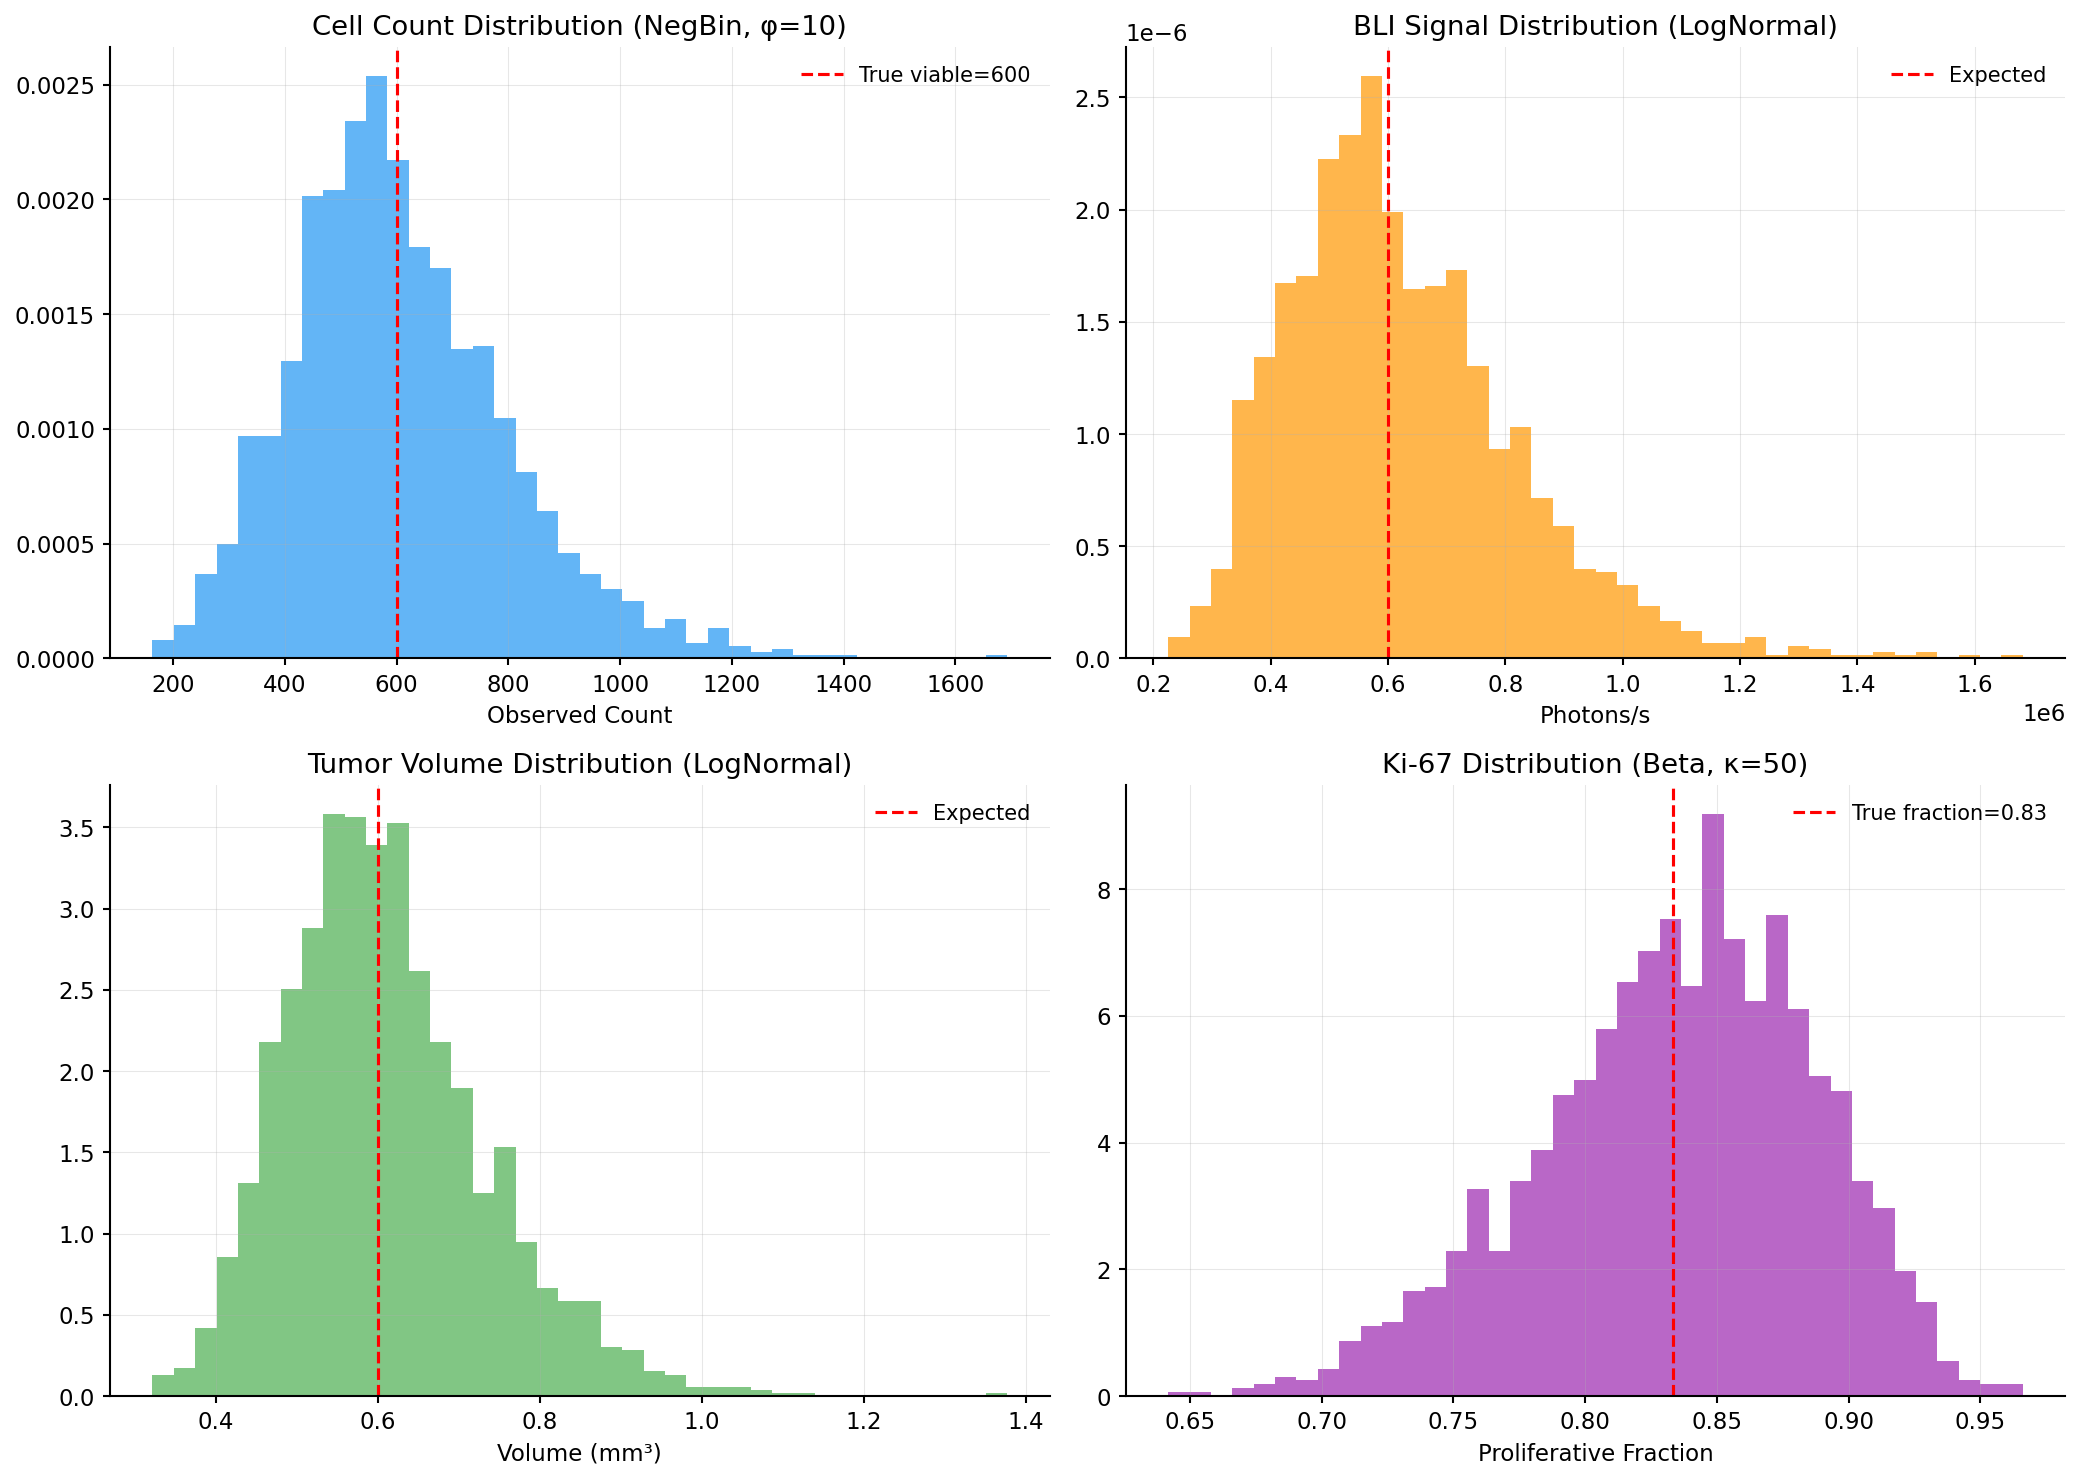

In [10]:
# --- Visualize observation noise distributions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cell counts
n_samples = 2000
counts = [obs_counts.sample(true_state, rng) for _ in range(n_samples)]
axes[0, 0].hist(counts, bins=40, density=True, alpha=0.7, color="#2196F3")
axes[0, 0].axvline(600, color="red", linestyle="--", label="True viable=600")
axes[0, 0].set_title("Cell Count Distribution (NegBin, φ=10)")
axes[0, 0].set_xlabel("Observed Count")
axes[0, 0].legend()

# BLI
blis = [obs_bli.sample(true_state, rng) for _ in range(n_samples)]
axes[0, 1].hist(blis, bins=40, density=True, alpha=0.7, color="#FF9800")
axes[0, 1].axvline(obs_bli.expected_value(true_state), color="red", linestyle="--", label="Expected")
axes[0, 1].set_title("BLI Signal Distribution (LogNormal)")
axes[0, 1].set_xlabel("Photons/s")
axes[0, 1].legend()

# Volume
vols = [obs_vol.sample(true_state, rng) for _ in range(n_samples)]
axes[1, 0].hist(vols, bins=40, density=True, alpha=0.7, color="#4CAF50")
axes[1, 0].axvline(obs_vol.expected_value(true_state), color="red", linestyle="--", label="Expected")
axes[1, 0].set_title("Tumor Volume Distribution (LogNormal)")
axes[1, 0].set_xlabel("Volume (mm³)")
axes[1, 0].legend()

# Ki-67
ki67s = [obs_ki67.sample(true_state, rng) for _ in range(n_samples)]
axes[1, 1].hist(ki67s, bins=40, density=True, alpha=0.7, color="#9C27B0")
axes[1, 1].axvline(true_frac, color="red", linestyle="--", label=f"True fraction={true_frac:.2f}")
axes[1, 1].set_title("Ki-67 Distribution (Beta, κ=50)")
axes[1, 1].set_xlabel("Proliferative Fraction")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [11]:
# --- Multimodal Fusion: combining modalities ---
multi_obs = MultimodalObservation(models={
    "cell_counts": obs_counts,
    "bli": obs_bli,
    "volume": obs_vol,
    "ki67": obs_ki67
})

# Sample all modalities at once
sample = multi_obs.sample(true_state, rng)
print("=== Multimodal Sample ===")
for modality, value in sample.items():
    print(f"  {modality:>12}: {value:.2f}")

# Compute joint log-likelihood
ll_all = multi_obs.log_likelihood(sample, true_state)
print(f"\nJoint log-likelihood (all modalities): {ll_all:.2f}")

# Missing data: just omit a modality
partial_obs = {"cell_counts": 610, "bli": None, "volume": 0.58, "ki67": None}
ll_partial = multi_obs.log_likelihood(partial_obs, true_state)
print(f"Partial log-likelihood (counts + volume only): {ll_partial:.2f}")
print("  → Missing modalities (None) are gracefully skipped")

=== Multimodal Sample ===
   cell_counts: 289.00
           bli: 349783.78
        volume: 0.55
          ki67: 0.81

Joint log-likelihood (all modalities): -18.58
Partial log-likelihood (counts + volume only): -4.98
  → Missing modalities (None) are gracefully skipped


### Interpretation

| Modality | Distribution | Key Parameter | When to Use |
|----------|-------------|---------------|-------------|
| Cell counts | Negative Binomial | φ (overdispersion) | In vitro plate assays (most common) |
| BLI | LogNormal | α (photons/cell), σ | In vivo bioluminescence imaging |
| Tumor volume | LogNormal | β (mm³/cell), σ | Caliper or MRI measurements |
| Ki-67 | Beta | κ (precision) | Immunohistochemistry snapshots |

**Multimodal fusion** combines all available modalities. Each measurement independently constrains the model — more modalities = better parameter identifiability.

---
## 8. Data Structures: How U-MIMIC Expects Your Data

Understanding the data format is critical for using U-MIMIC with your own experiments.

In [12]:
# =============================================
# 8a. TimeSeriesData: a single replicate
# =============================================

# Simulated: one well of a 96-well plate, treated with 1.0 µM drug
# Measurements taken every 4 hours for 72 hours
times = np.array([0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72])

# Simulated cell counts (with realistic noise)
true_growth = 100 * np.exp(0.02 * times)  # underlying truth
noisy_counts = rng.negative_binomial(
    n=10,  # overdispersion parameter
    p=10 / (10 + true_growth)
) + true_growth.astype(int)  # simplified noisy counts
noisy_counts = np.maximum(noisy_counts, 1).astype(float)

# Create a TimeSeriesData object
ts_data = TimeSeriesData(
    times=times,
    observations={"cell_counts": noisy_counts},
    concentration=1.0,        # constant drug concentration (in vitro)
    group_id="well_A1",
    metadata={"cell_line": "MCF7", "drug": "Doxorubicin"}
)

print("=== TimeSeriesData Structure ===")
print(f"Time points:     {ts_data.n_timepoints}")
print(f"Modalities:      {ts_data.modalities}")
print(f"Concentration:   {ts_data.concentration} µM")
print(f"Group ID:        {ts_data.group_id}")
print(f"Has cell_counts: {ts_data.has_modality('cell_counts')}")
print(f"Has BLI:         {ts_data.has_modality('bli')}")
print(f"\nFirst 5 time points:")
for i in range(5):
    print(f"  t={ts_data.times[i]:5.1f}h  count={ts_data.get_observation('cell_counts', i):.0f}")

# Quick factory method from counts
ts_quick = TimeSeriesData.from_counts(
    times=np.array([0, 24, 48, 72]),
    counts=np.array([100, 180, 310, 520]),
    concentration=0.0,
    group_id="control_1"
)
print(f"\n=== Quick Factory ===")
print(f"Created from_counts: {ts_quick.n_timepoints} time points, conc={ts_quick.concentration}")

=== TimeSeriesData Structure ===
Time points:     19
Modalities:      ['cell_counts']
Concentration:   1.0 µM
Group ID:        well_A1
Has cell_counts: True
Has BLI:         False

First 5 time points:
  t=  0.0h  count=181
  t=  4.0h  count=203
  t=  8.0h  count=302
  t= 12.0h  count=242
  t= 16.0h  count=348

=== Quick Factory ===
Created from_counts: 4 time points, conc=0.0


In [13]:
# =============================================
# 8b. ExperimentalDataset: the full experiment
# =============================================

# Simulated: a dose-response plate experiment
# 5 drug concentrations × 3 replicate wells each = 15 time series
concs = [0.0, 0.1, 0.5, 1.0, 5.0]
net_growth_rates = [0.03, 0.025, 0.015, 0.005, -0.01]  # decreasing with dose
times_plate = np.arange(0, 73, 4)

all_series = []
for conc, ngr in zip(concs, net_growth_rates):
    for rep in range(3):
        # Simulate noisy growth curve
        true_curve = 100 * np.exp(ngr * times_plate)
        noise = rng.normal(0, 0.1 * true_curve)
        observed = np.maximum(true_curve + noise, 1).astype(float)
        
        series = TimeSeriesData(
            times=times_plate,
            observations={"cell_counts": observed},
            concentration=conc,
            group_id=f"well_{conc}uM_rep{rep+1}"
        )
        all_series.append(series)

dataset = ExperimentalDataset(
    series=all_series,
    name="MCF7_Doxorubicin_DoseResponse",
    context="in_vitro"
)

print("=== ExperimentalDataset Structure ===")
print(f"Name:           {dataset.name}")
print(f"Context:        {dataset.context}")
print(f"Total series:   {dataset.n_series}")
print(f"Concentrations: {dataset.concentrations}")
print(f"Group IDs:      {dataset.group_ids[:6]}...")

# Filtering
control = dataset.by_concentration(0.0)
print(f"\nControl wells (0 µM): {len(control)} replicates")

well = dataset.by_group("well_1.0uM_rep1")
print(f"Single well lookup: {well.group_id}, conc={well.concentration} µM")

=== ExperimentalDataset Structure ===
Name:           MCF7_Doxorubicin_DoseResponse
Context:        in_vitro
Total series:   15
Concentrations: [0.0, 0.1, 0.5, 1.0, 5.0]
Group IDs:      ['well_0.0uM_rep1', 'well_0.0uM_rep2', 'well_0.0uM_rep3', 'well_0.1uM_rep1', 'well_0.1uM_rep2', 'well_0.1uM_rep3']...

Control wells (0 µM): 3 replicates
Single well lookup: well_1.0uM_rep1, conc=1.0 µM


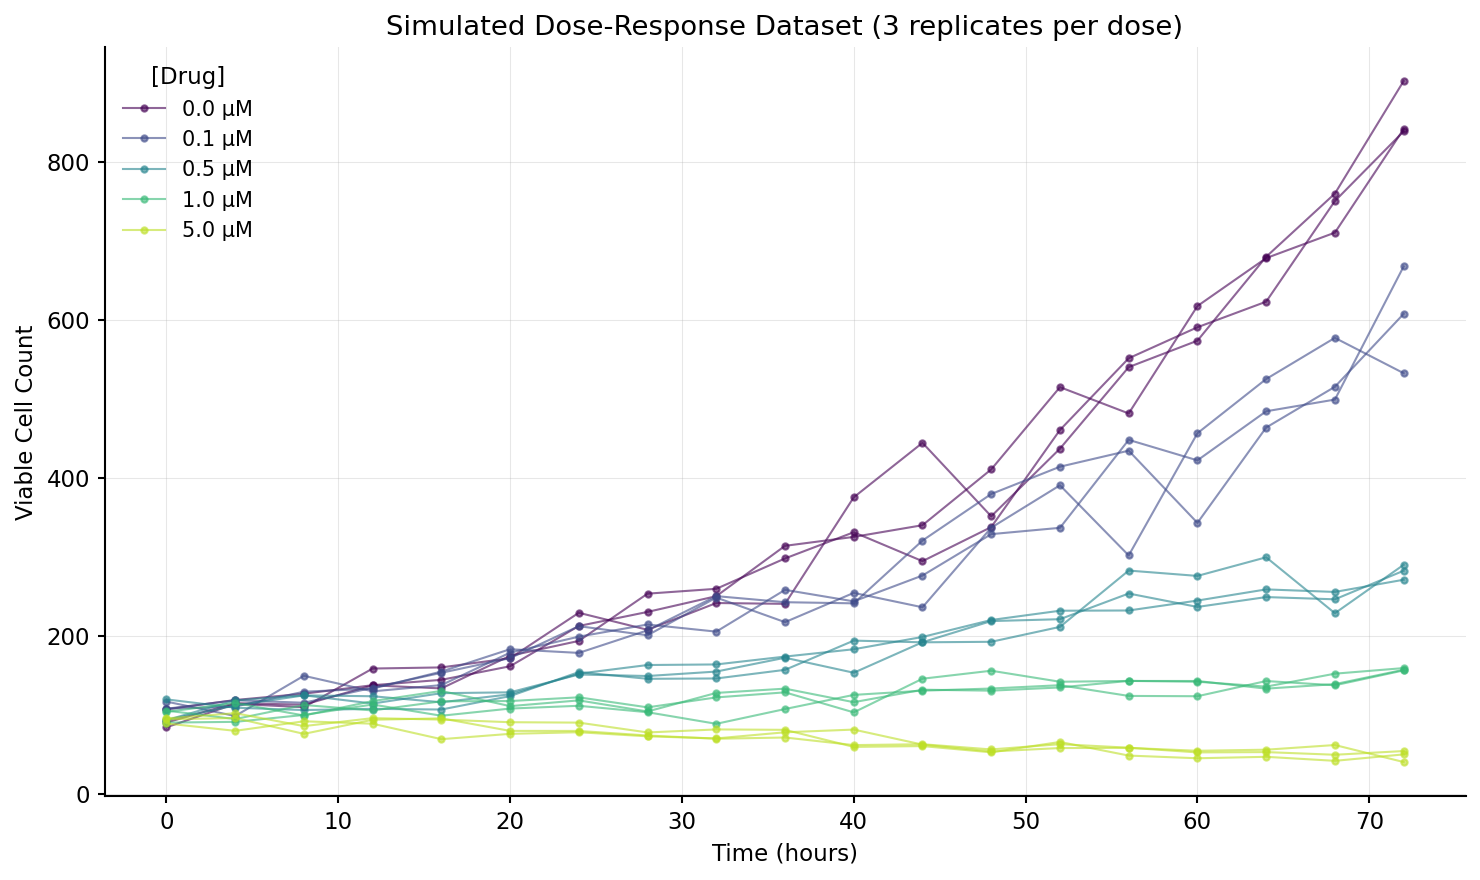


=== Data Format for CSV Import ===
Your CSV file should look like this:

hours,viable_count,concentration,replicate_id
0.0,107,0.0,well_0.0uM_rep1
4.0,119,0.0,well_0.0uM_rep1
8.0,127,0.0,well_0.0uM_rep1
...
0.0,84,0.0,well_0.0uM_rep2
4.0,114,0.0,well_0.0uM_rep2
8.0,110,0.0,well_0.0uM_rep2
...


In [14]:
# --- Visualize the simulated dataset ---
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(concs)))
for i, conc in enumerate(concs):
    series_at_conc = dataset.by_concentration(conc)
    for j, s in enumerate(series_at_conc):
        label = f"{conc} µM" if j == 0 else None
        ax.plot(s.times, s.observations["cell_counts"],
                color=colors[i], alpha=0.6, marker="o", markersize=3,
                linewidth=1, label=label)

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Viable Cell Count")
ax.set_title("Simulated Dose-Response Dataset (3 replicates per dose)")
ax.legend(title="[Drug]", loc="upper left")
plt.tight_layout()
plt.show()

print("\n=== Data Format for CSV Import ===")
print("Your CSV file should look like this:")
print()
print("hours,viable_count,concentration,replicate_id")
for s in all_series[:2]:  # show first 2 series
    for k in range(min(3, len(s.times))):
        print(f"{s.times[k]:.1f},{s.observations['cell_counts'][k]:.0f},{s.concentration},{s.group_id}")
    print("...")

### Interpretation

**`TimeSeriesData`** = one replicate (one well, one animal):
- `times`: array of measurement time points
- `observations`: dictionary mapping modality name → measurement array
- `concentration`: drug concentration (constant for in vitro)
- `group_id`: unique replicate identifier

**`ExperimentalDataset`** = the full experiment (all replicates across all conditions):
- Can filter by concentration or group ID
- Can be loaded from CSV via `load_csv()`

**CSV Format**: `hours, viable_count, concentration, replicate_id` (one row per observation).

---
## 9. Synthetic Data Generation

U-MIMIC can generate realistic synthetic datasets for validation and experimental design. This uses the full stochastic model + observation noise.

In [15]:
# --- Set up the synthetic data generator ---
topology = ModelTopology.two_state()

# True parameters (these are the values we want to recover later)
TRUE_PARAMS = {
    "b0": 0.04,
    "d0": 0.01,
    "emax_death": 0.05,
    "ec50_death": 1.0,
    "hill_death": 1.5,
}

true_rates = RateSet.cytotoxic_drug(**TRUE_PARAMS)
obs_model = CellCountObservation(overdispersion=10.0)

generator = SyntheticDataGenerator(
    rate_set=true_rates,
    topology=topology,
    observation_model=obs_model,
    rng=np.random.default_rng(123)
)

# --- Generate in vitro plate experiment ---
synth_dataset = generator.generate_invitro_plate(
    initial_cells=np.array([100, 0]),   # 100 P, 0 Q
    concentrations=[0.0, 0.1, 0.5, 1.0, 2.0, 5.0],
    n_wells_per_dose=4,
    t_max=72.0,
    dt_obs=4.0,
    method="gillespie"
)

print("=== Synthetic In Vitro Dataset ===")
print(f"Total series: {synth_dataset.n_series}")
print(f"Concentrations: {synth_dataset.concentrations}")
print(f"Context: {synth_dataset.context}")
print(f"\nSample series (first well at 0 µM):")
s0 = synth_dataset.by_concentration(0.0)[0]
print(f"  Times: {s0.times[:5]}... ({s0.n_timepoints} points)")
print(f"  Counts: {s0.observations['cell_counts'][:5].astype(int)}...")

=== Synthetic In Vitro Dataset ===
Total series: 24
Concentrations: [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
Context: in_vitro

Sample series (first well at 0 µM):
  Times: [ 0.  4.  8. 12. 16.]... (19 points)
  Counts: [ 82  78 160 196  97]...


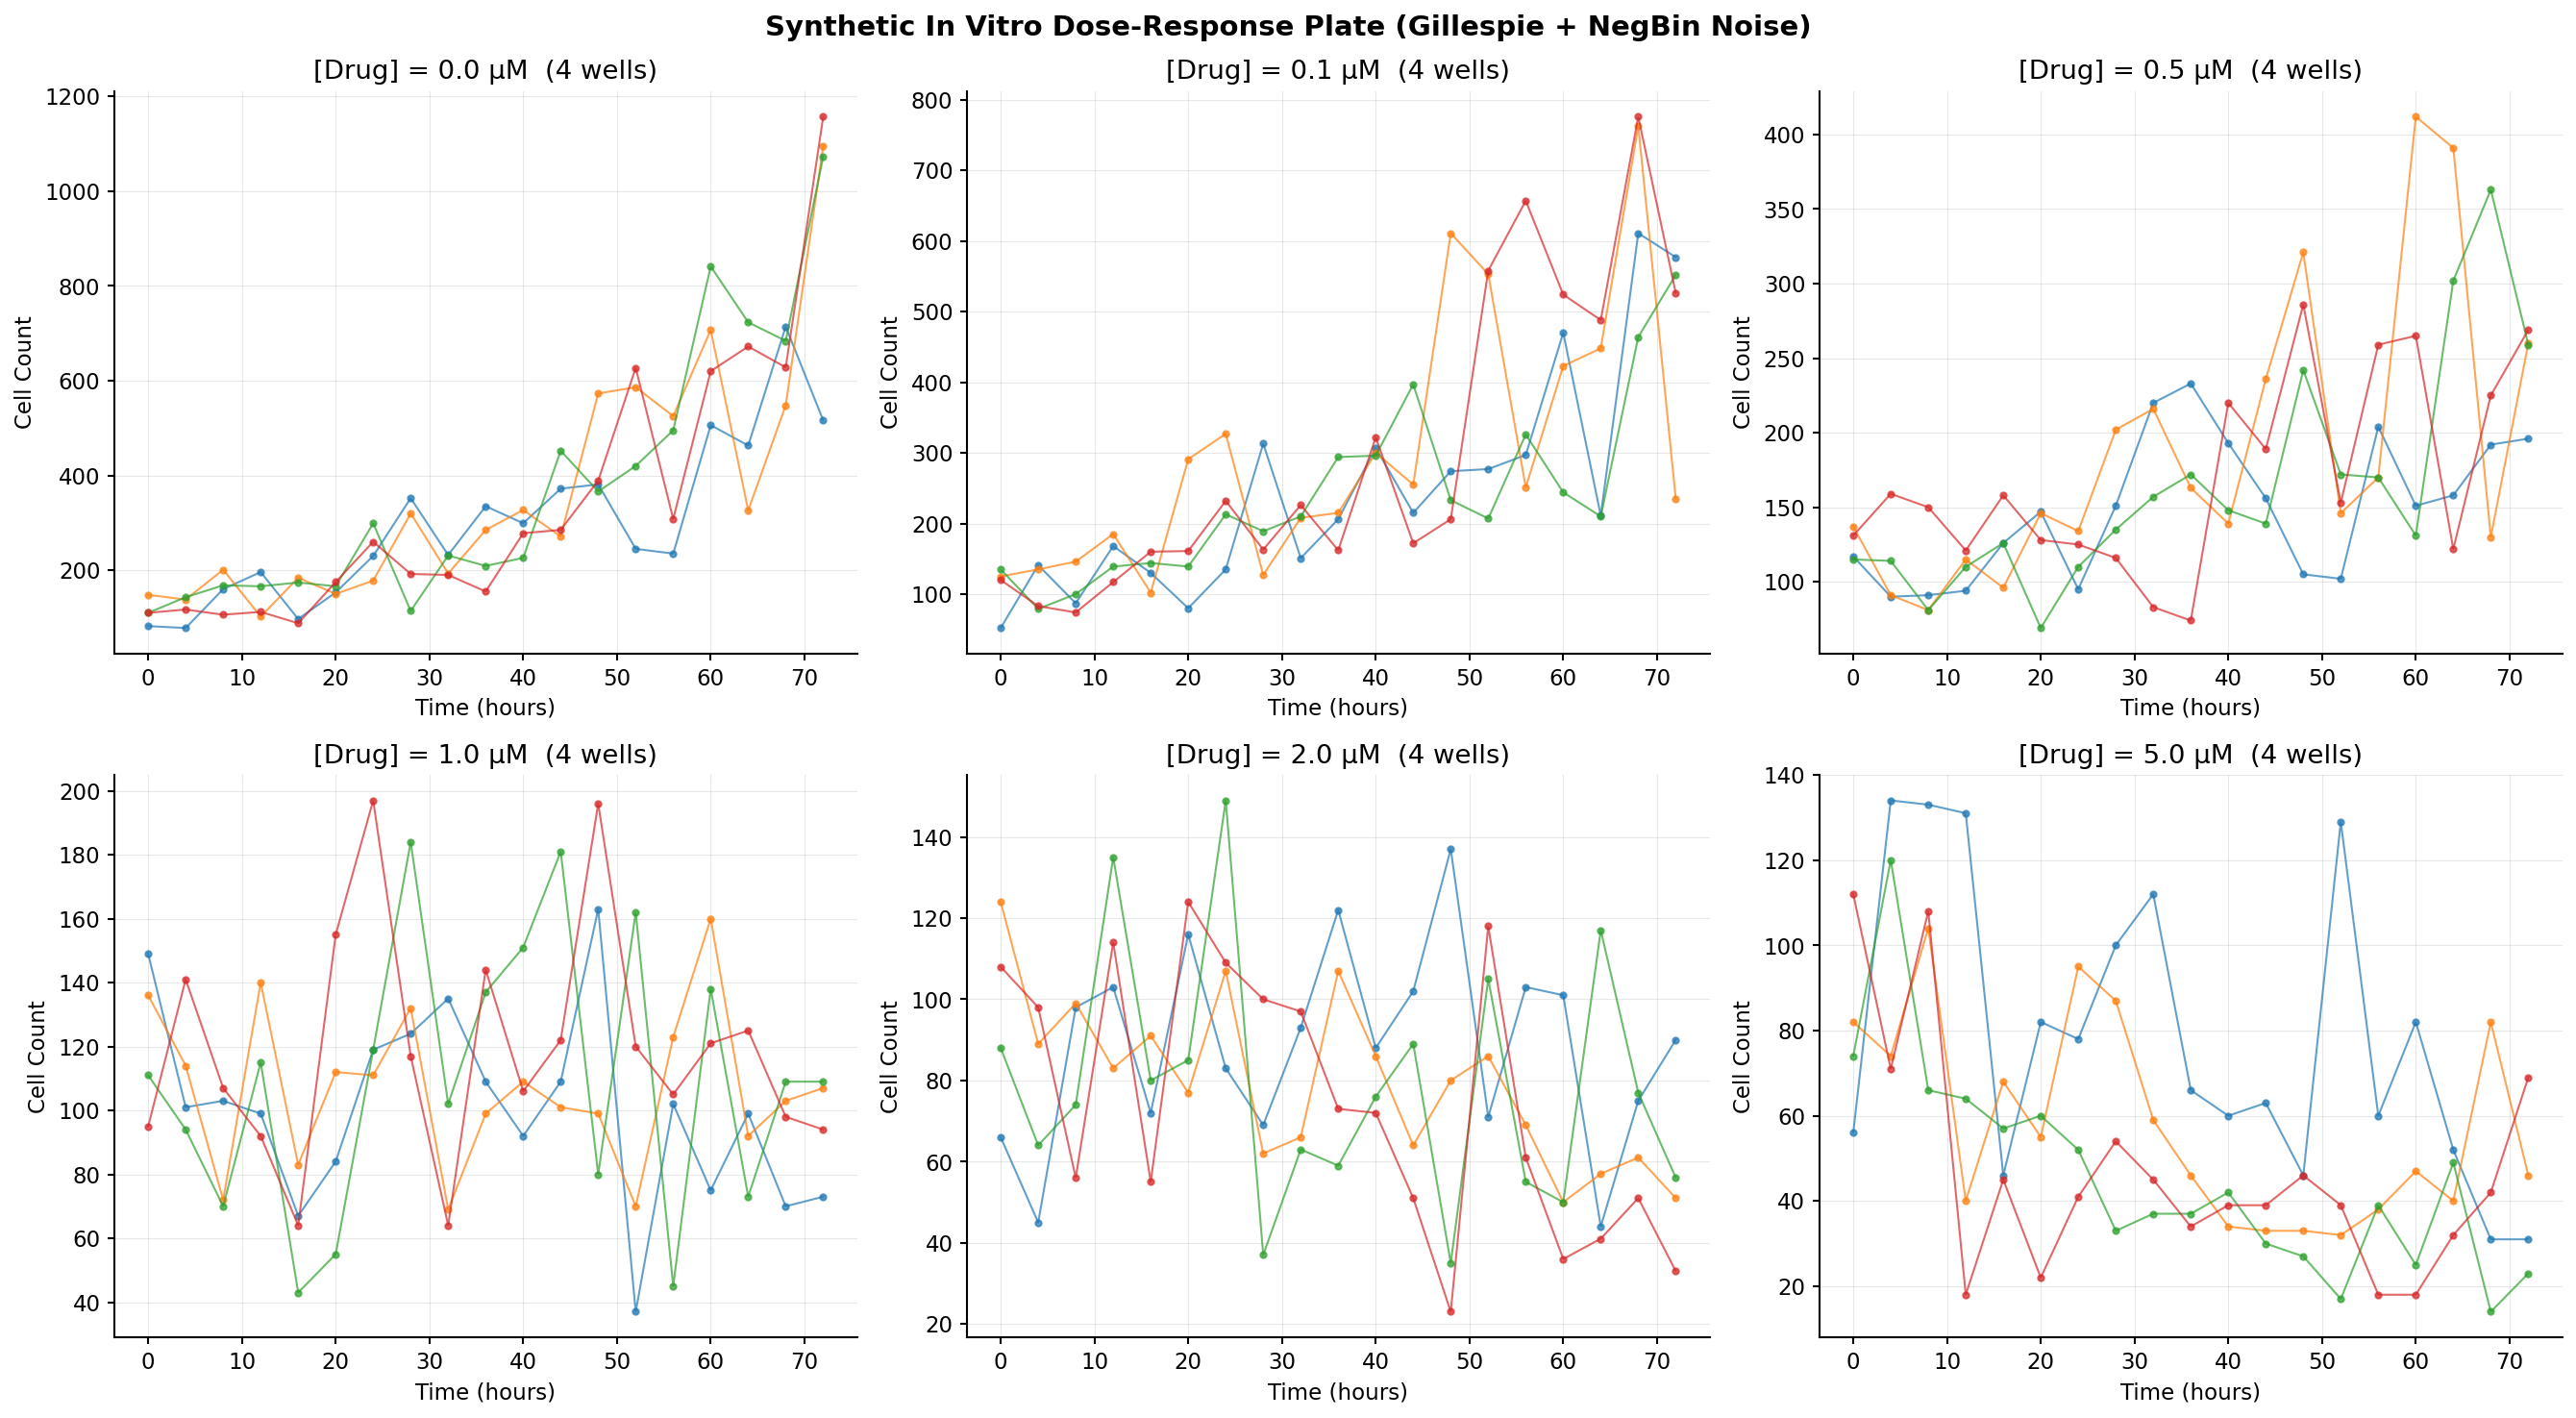


Key observations:
• 0 µM: Exponential growth (control)
• 0.1-0.5 µM: Slowed growth
• 1-2 µM: Near-static or declining
• 5 µM: Population decline (drug kills cells faster than they divide)
• Each well shows stochastic variation around the same underlying dynamics


In [16]:
# --- Visualize synthetic data ---
synth_concs = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, conc in enumerate(synth_concs):
    series_list = synth_dataset.by_concentration(conc)
    ax = axes[i]
    for s in series_list:
        ax.plot(s.times, s.observations["cell_counts"],
                marker="o", markersize=3, alpha=0.7, linewidth=1)
    
    ax.set_title(f"[Drug] = {conc} µM  ({len(series_list)} wells)")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Cell Count")

fig.suptitle("Synthetic In Vitro Dose-Response Plate (Gillespie + NegBin Noise)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("• 0 µM: Exponential growth (control)")
print("• 0.1-0.5 µM: Slowed growth")
print("• 1-2 µM: Near-static or declining")
print("• 5 µM: Population decline (drug kills cells faster than they divide)")
print("• Each well shows stochastic variation around the same underlying dynamics")

---
## 10. Parameter Inference: Maximum Likelihood (MLE)

Now for the core question: **given experimental data, can we recover the underlying biological parameters?**

MLE finds the parameter values that maximize the probability of the observed data.

In [17]:
# --- Prepare data for inference ---
# Use data from a single concentration (1.0 µM) with multiple replicates
data_for_mle = synth_dataset.by_concentration(1.0)

print(f"Using {len(data_for_mle)} replicate wells at 1.0 µM")
print(f"Each has {data_for_mle[0].n_timepoints} time points")

# --- Build the likelihood function ---
likelihood = ModelLikelihood(
    topology=topology,
    data=data_for_mle,
    mode="moment",                    # Use LNA (moment equations) for speed
    observation_model=obs_model
)

print(f"\nLikelihood setup:")
print(f"  Parameters: {likelihood.param_names}")
print(f"  Num params: {likelihood.n_params}")

Using 4 replicate wells at 1.0 µM
Each has 19 time points

Likelihood setup:
  Parameters: ['b0', 'd0_P', 'emax_death', 'ec50_death', 'hill_death', 'u_PQ', 'u_QP', 'overdispersion']
  Num params: 8


In [18]:
# --- Run MLE optimization ---
estimator = MLEstimator(
    likelihood=likelihood,
    method="L-BFGS-B"    # gradient-based bounded optimization
)

mle_result = estimator.fit(n_restarts=5)  # 5 random restarts for robustness

print("=== MLE Results ===")
print(f"Converged: {mle_result.converged}")
print(f"Log-likelihood: {mle_result.log_likelihood:.2f}")
print(f"AIC: {mle_result.aic:.2f}")
print(f"BIC: {mle_result.bic:.2f}")
print(f"Evaluations: {mle_result.n_evaluations}")
print()
print(f"{'Parameter':>15} | {'Estimated':>10} | {'True':>10} | {'Std Error':>10}")
print("-" * 55)
for name, est_val in mle_result.parameters.items():
    true_val = TRUE_PARAMS.get(name, "—")
    se = mle_result.se.get(name, float('nan')) if mle_result.se else float('nan')
    if isinstance(true_val, float):
        print(f"{name:>15} | {est_val:>10.4f} | {true_val:>10.4f} | {se:>10.4f}")
    else:
        print(f"{name:>15} | {est_val:>10.4f} | {'—':>10} | {se:>10.4f}")

=== MLE Results ===
Converged: True
Log-likelihood: -382.45
AIC: 780.91
BIC: 799.55
Evaluations: 2234

      Parameter |  Estimated |       True |  Std Error
-------------------------------------------------------
             b0 |     0.0001 |     0.0400 |     0.1188
           d0_P |     0.0100 |          — |     0.0417
     emax_death |     0.3213 |     0.0500 |    26.7651
     ec50_death |    67.4538 |     1.0000 |    35.2570
     hill_death |     3.4281 |     1.5000 |    29.3962
           u_PQ |     0.0500 |          — |     0.4817
           u_QP |     0.0000 |          — |     0.0000
 overdispersion |    10.7396 |          — |     2.0258


In [19]:
# --- Examine the MLEResult object ---
print("=== MLEResult Structure ===")
print(f"Type: {type(mle_result).__name__}")
print()
print("Fields:")
print(f"  .parameters     : dict[str, float]    — {len(mle_result.parameters)} estimated values")
print(f"  .log_likelihood : float               — {mle_result.log_likelihood:.2f}")
print(f"  .aic            : float               — {mle_result.aic:.2f} (lower = better)")
print(f"  .bic            : float               — {mle_result.bic:.2f} (lower = better)")
print(f"  .se             : dict[str, float]     — standard errors from Hessian")
print(f"  .converged      : bool                — {mle_result.converged}")
print(f"  .n_evaluations  : int                 — {mle_result.n_evaluations} likelihood evals")
print(f"  .hessian        : np.ndarray | None   — {'present' if mle_result.hessian is not None else 'None'}")
print()
print("Interpretation:")
print("  • AIC/BIC: Use for model comparison (e.g., 2-state vs. 3-state)")
print("  • Standard errors: Approximate uncertainty (from Fisher information)")
print("  • If SE is large relative to estimate → parameter is poorly identified")

=== MLEResult Structure ===
Type: MLEResult

Fields:
  .parameters     : dict[str, float]    — 8 estimated values
  .log_likelihood : float               — -382.45
  .aic            : float               — 780.91 (lower = better)
  .bic            : float               — 799.55 (lower = better)
  .se             : dict[str, float]     — standard errors from Hessian
  .converged      : bool                — True
  .n_evaluations  : int                 — 2234 likelihood evals
  .hessian        : np.ndarray | None   — present

Interpretation:
  • AIC/BIC: Use for model comparison (e.g., 2-state vs. 3-state)
  • Standard errors: Approximate uncertainty (from Fisher information)
  • If SE is large relative to estimate → parameter is poorly identified


### Interpretation

- **Converged = True**: The optimizer found a stable minimum.
- Compare **Estimated** vs. **True** values — they should be close (but not exact due to noise).
- **Standard errors** indicate parameter uncertainty: small SE → well-determined, large SE → uncertain.
- **AIC/BIC**: Lower values indicate better model fit. Use these to compare different model topologies.
- MLE gives **point estimates** only — for full uncertainty quantification, use MCMC (next section).

---
## 11. Parameter Inference: Bayesian (MCMC)

MCMC provides **full posterior distributions** over parameters — not just point estimates, but complete uncertainty quantification.

In [20]:
# --- Set up priors ---
# Weakly informative priors that encode reasonable biological ranges
priors = PriorSpec.default_invitro()

print("=== Default In Vitro Priors ===")
for name in priors.param_names:
    # Sample a few values to show the prior range
    samples = [priors.distributions[name].rvs() for _ in range(1000)]
    print(f"  {name:>15}: median={np.median(samples):.4f}, "
          f"95% range=[{np.percentile(samples, 2.5):.4f}, {np.percentile(samples, 97.5):.4f}]")

=== Default In Vitro Priors ===
               b0: median=0.0387, 95% range=[0.0152, 0.1059]
             d0_P: median=0.0102, 95% range=[0.0037, 0.0269]
       emax_death: median=0.0670, 95% range=[0.0034, 0.2137]
       ec50_death: median=0.9641, 95% range=[0.1480, 7.3594]
       hill_death: median=1.5139, 95% range=[0.8025, 2.6559]
             u_PQ: median=0.0049, 95% range=[0.0019, 0.0122]
             u_QP: median=0.0029, 95% range=[0.0011, 0.0083]
   overdispersion: median=9.8576, 95% range=[3.6698, 27.5515]


In [21]:
# --- Run MCMC ---
sampler = MCMCSampler(
    likelihood=likelihood,
    priors=priors,
    backend="emcee"      # Affine-invariant ensemble sampler (always available)
)

print("Running MCMC (this may take a few minutes)...")
mcmc_result = sampler.sample(
    n_samples=2000,
    n_chains=4,
    n_warmup=1000,
    initial_guess=np.array(list(mle_result.parameters.values()))  # start from MLE
)
print("Done!")

Running MCMC (this may take a few minutes)...


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [161.2413478  189.63232916 181.76797606 150.43747314 135.64835342
 124.73596441 121.98248263 129.46524978]


Done!


In [22]:
# --- Examine MCMC results ---
print("=== MCMCResult Structure ===")
print(f"Type: {type(mcmc_result).__name__}")
print(f"Chains: {mcmc_result.n_chains}")
print(f"Samples per chain: {mcmc_result.n_samples}")
print()

# Posterior summaries
means = mcmc_result.posterior_mean()
stds = mcmc_result.posterior_std()
cis = mcmc_result.credible_interval(alpha=0.05)  # 95% credible intervals

print(f"{'Parameter':>15} | {'Post. Mean':>10} | {'Post. Std':>10} | {'95% CI':>22} | {'True':>8}")
print("-" * 76)
for name in means:
    true_val = TRUE_PARAMS.get(name, None)
    ci = cis[name]
    true_str = f"{true_val:.4f}" if true_val is not None else "—"
    print(f"{name:>15} | {means[name]:>10.4f} | {stds[name]:>10.4f} | "
          f"[{ci[0]:>8.4f}, {ci[1]:>8.4f}] | {true_str:>8}")

=== MCMCResult Structure ===
Type: MCMCResult
Chains: 18
Samples per chain: 2000

      Parameter | Post. Mean |  Post. Std |                 95% CI |     True
----------------------------------------------------------------------------
             b0 |     0.0218 |     0.0074 | [  0.0103,   0.0379] |   0.0400
           d0_P |     0.0139 |     0.0068 | [  0.0038,   0.0290] |        —
     emax_death |     0.0736 |     0.0556 | [  0.0035,   0.2076] |   0.0500
     ec50_death |     3.2453 |     3.1536 | [  0.2929,  12.5099] |   1.0000
     hill_death |     1.5044 |     0.4317 | [  0.8450,   2.5326] |   1.5000
           u_PQ |     0.0068 |     0.0041 | [  0.0020,   0.0171] |        —
           u_QP |     0.0038 |     0.0023 | [  0.0011,   0.0099] |        —
 overdispersion |    11.5311 |     2.4237 | [  7.4236,  16.8683] |        —


In [23]:
# --- MCMC Diagnostics ---
diagnostics = summarize_mcmc(mcmc_result)

print("=== MCMC Diagnostics ===")
print(f"{'Parameter':>15} | {'R-hat':>8} | {'ESS':>8} | {'Status':>10}")
print("-" * 50)
for name in mcmc_result.samples:
    rhat = diagnostics.get(f"{name}_rhat", diagnostics.get("rhat", {}).get(name, float('nan')))
    ess = diagnostics.get(f"{name}_ess", diagnostics.get("ess", {}).get(name, float('nan')))
    if isinstance(rhat, (int, float)):
        status = "OK" if rhat < 1.05 else "WARN"
        print(f"{name:>15} | {rhat:>8.3f} | {ess:>8.0f} | {status:>10}")

print()
print("Diagnostic guidelines:")
print("  R-hat < 1.05 : Chains have converged (good)")
print("  R-hat > 1.10 : Chains haven't mixed (run longer / check model)")
print("  ESS > 400    : Sufficient effective samples (good)")
print("  ESS < 100    : Need more samples")

=== MCMC Diagnostics ===
      Parameter |    R-hat |      ESS |     Status
--------------------------------------------------
             b0 |      nan |      nan |       WARN
           d0_P |      nan |      nan |       WARN
     emax_death |      nan |      nan |       WARN
     ec50_death |      nan |      nan |       WARN
     hill_death |      nan |      nan |       WARN
           u_PQ |      nan |      nan |       WARN
           u_QP |      nan |      nan |       WARN
 overdispersion |      nan |      nan |       WARN

Diagnostic guidelines:
  R-hat < 1.05 : Chains have converged (good)
  R-hat > 1.10 : Chains haven't mixed (run longer / check model)
  ESS > 400    : Sufficient effective samples (good)
  ESS < 100    : Need more samples


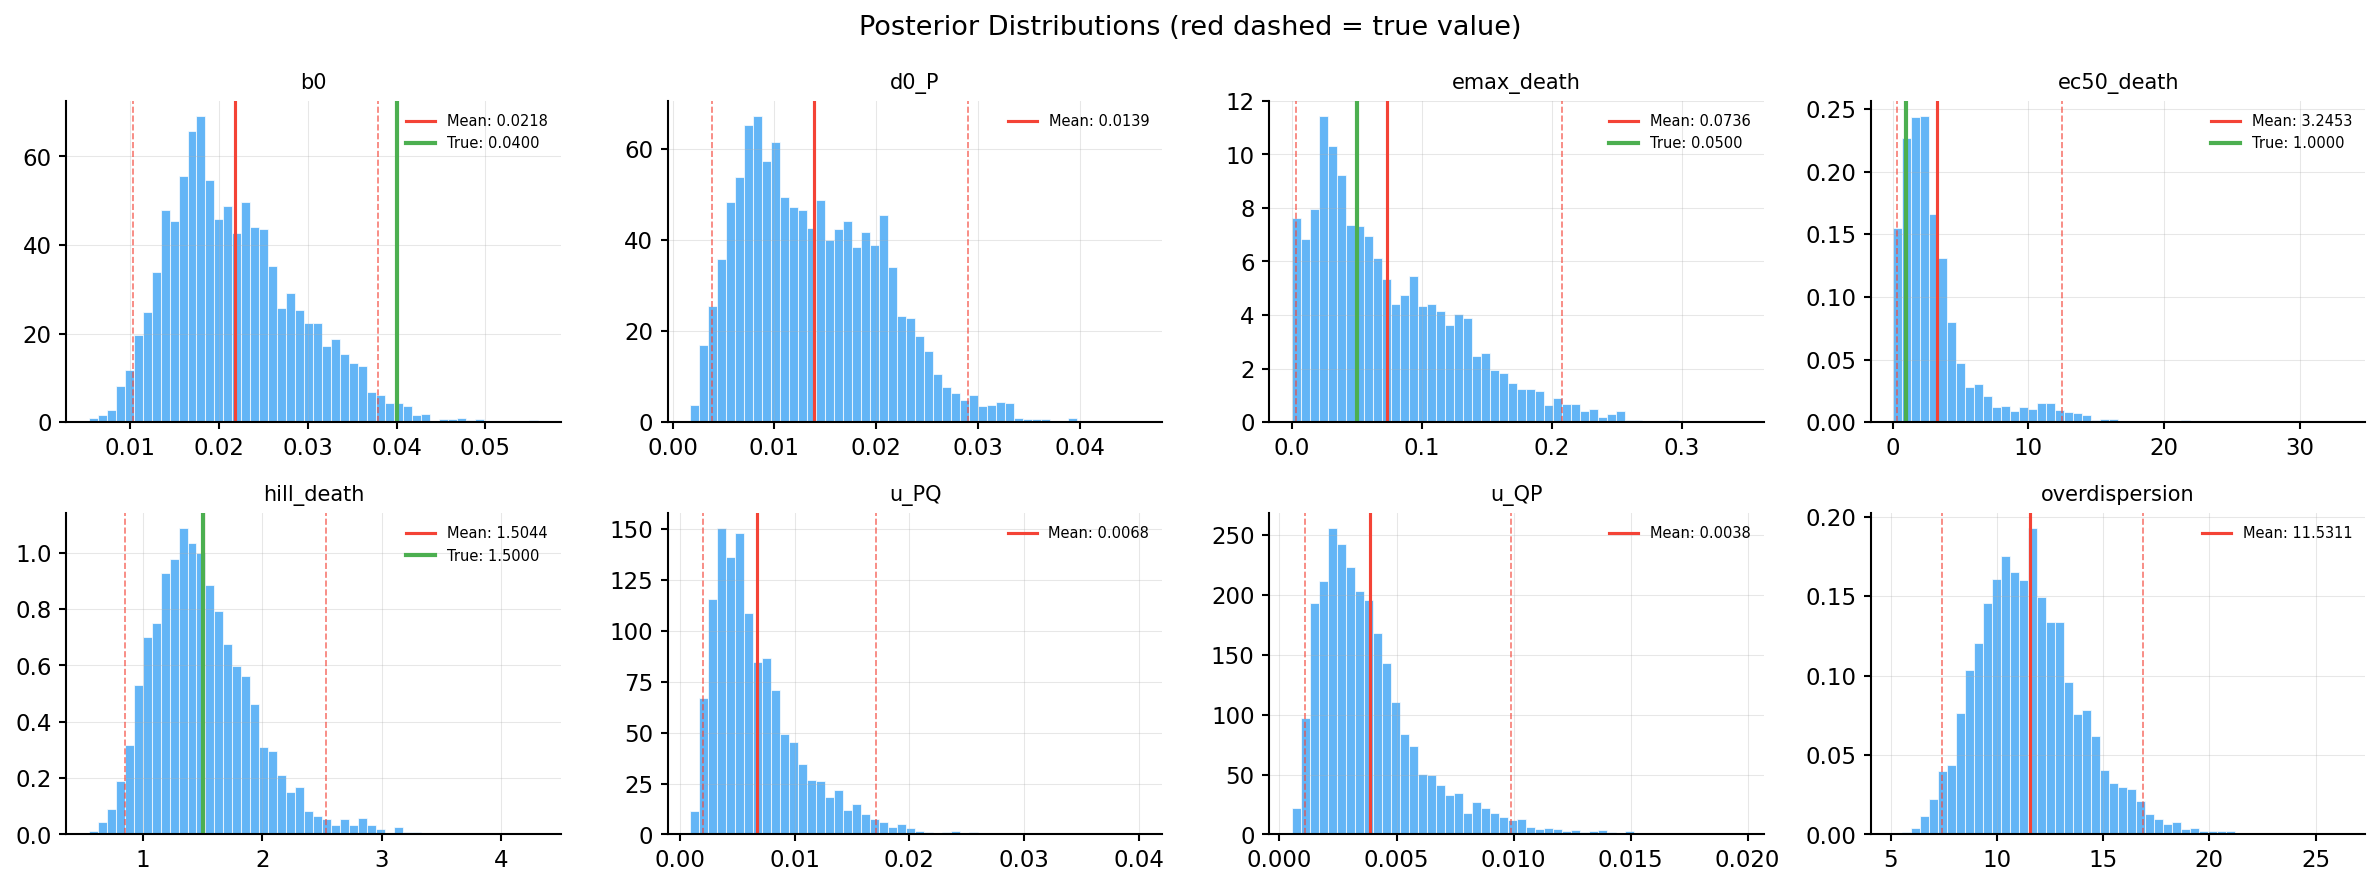

In [24]:
# --- Visualize posteriors ---
fig = plot_posterior_marginals(
    mcmc_result,
    true_values=TRUE_PARAMS  # overlay true values for validation
)
plt.suptitle("Posterior Distributions (red dashed = true value)", fontsize=13)
plt.tight_layout()
plt.show()

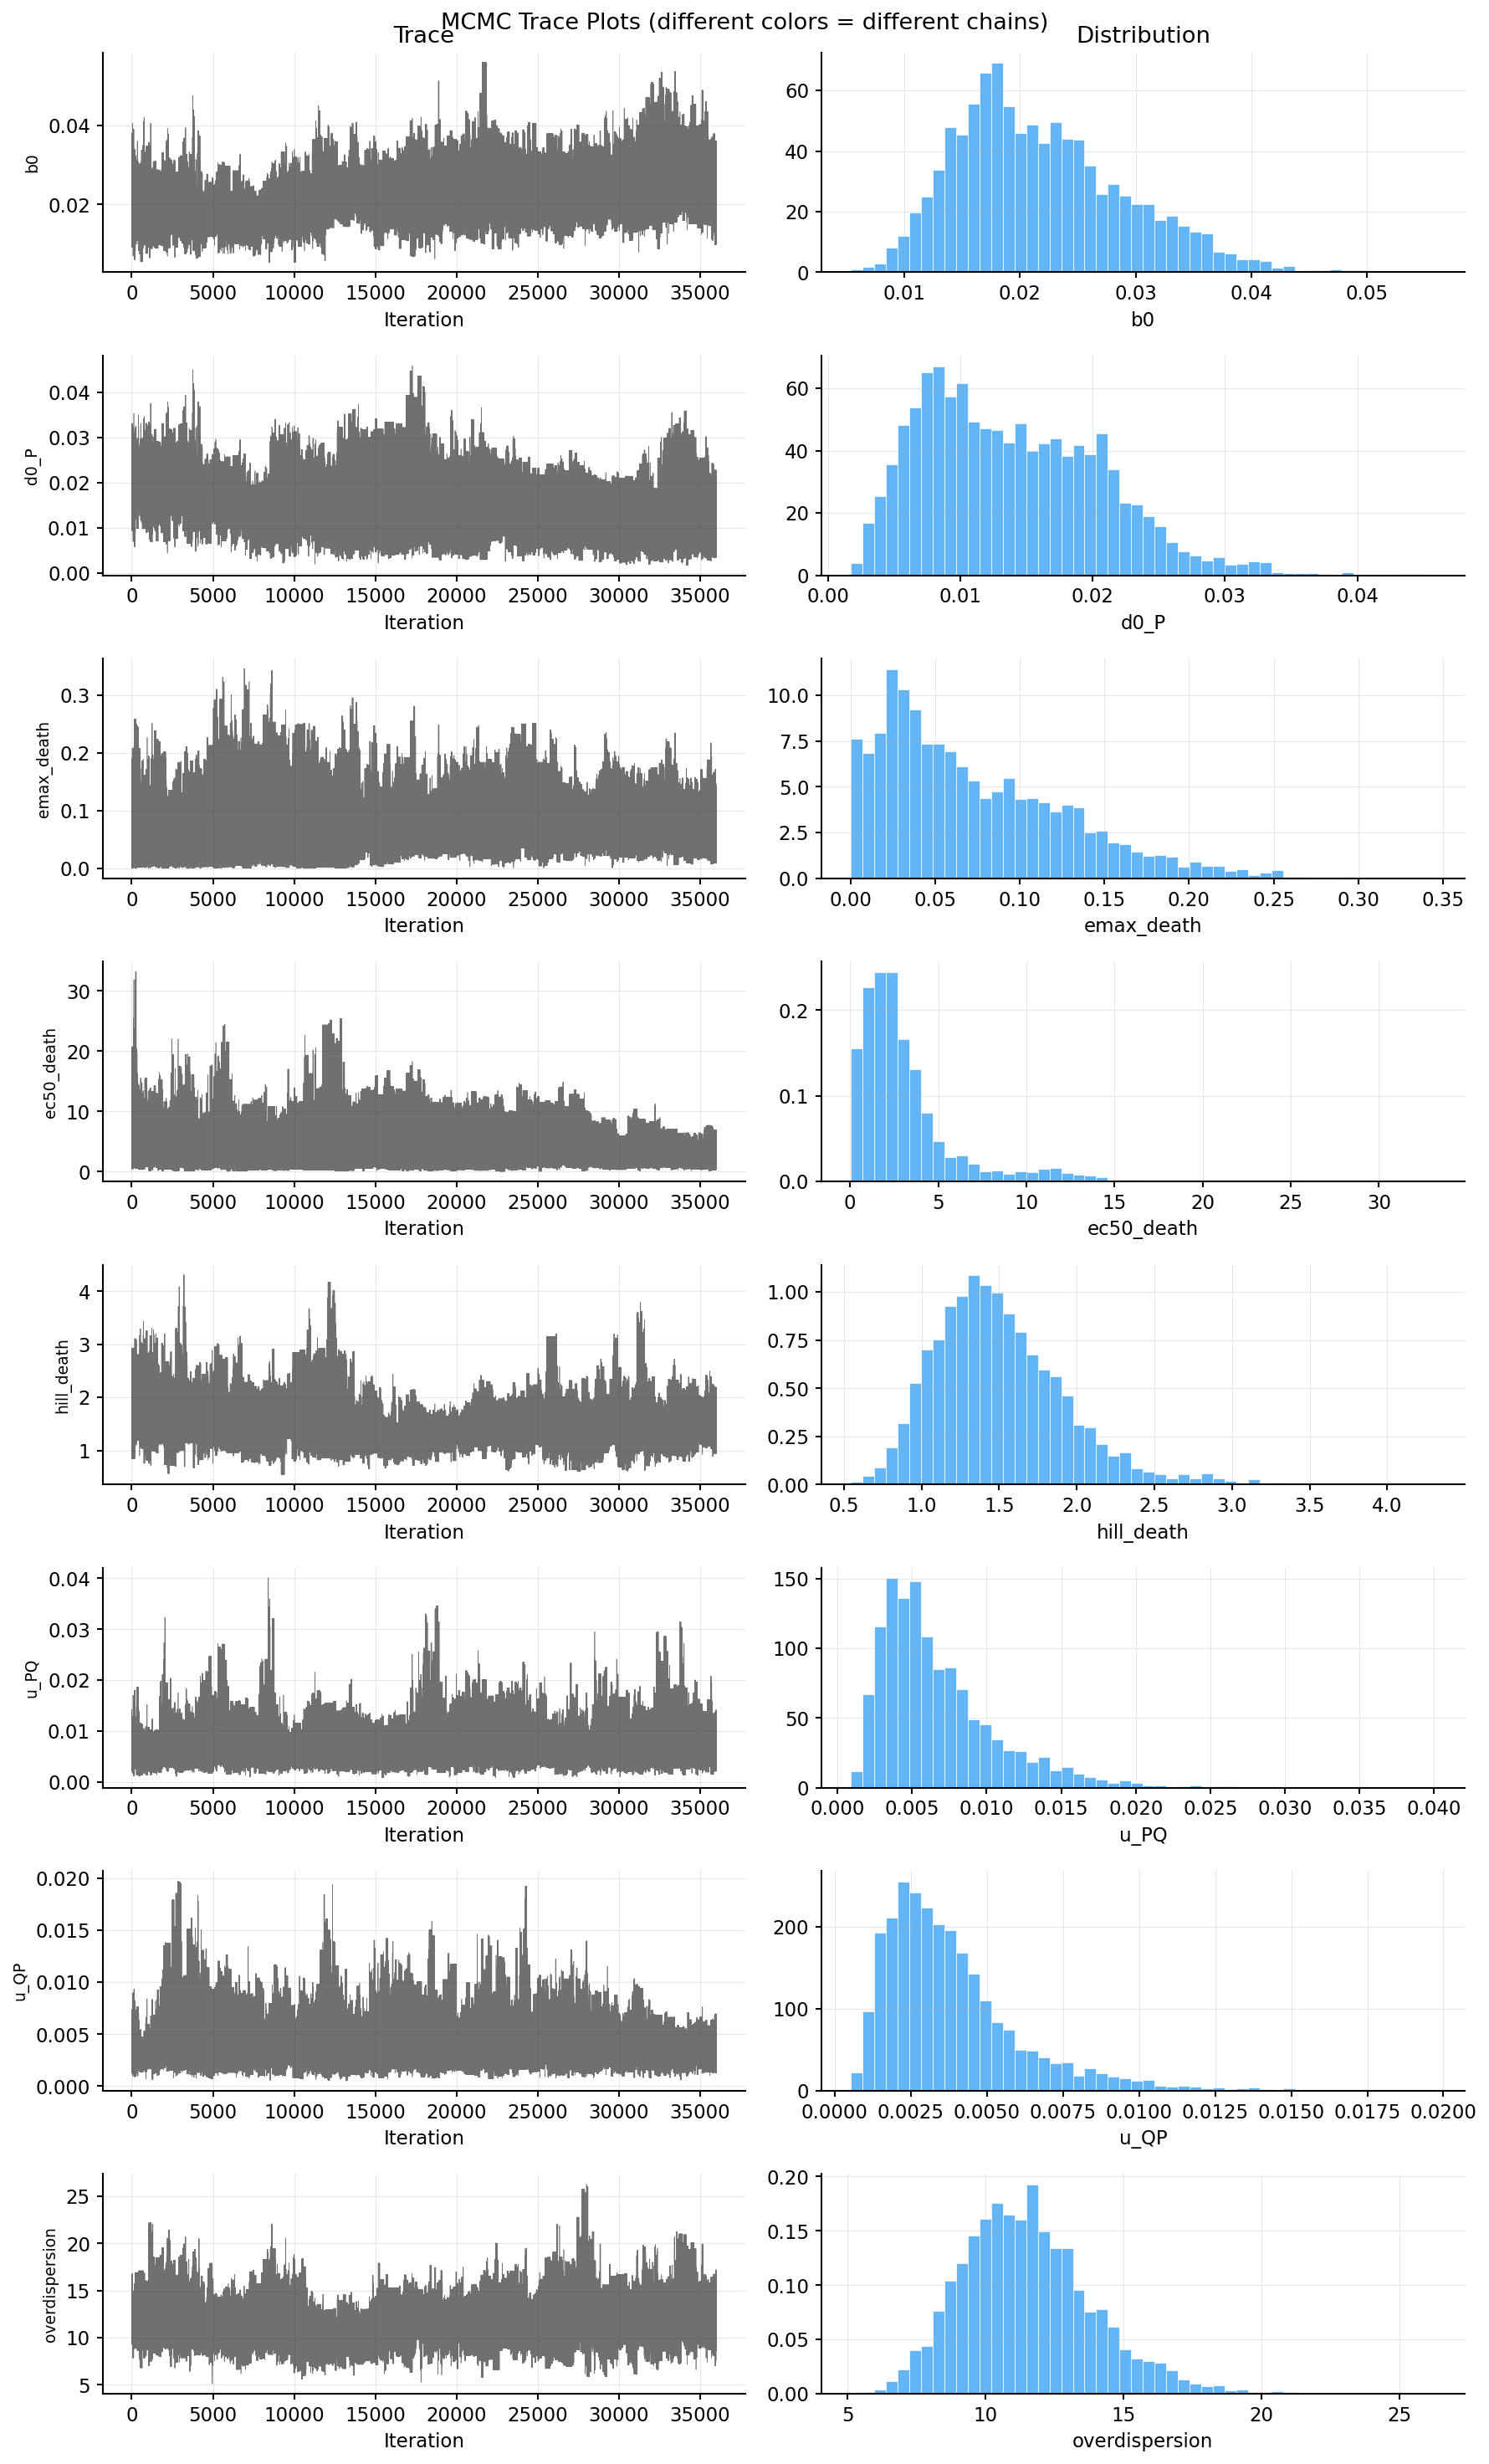

Trace plot interpretation:
  • Good mixing: chains look like 'fuzzy caterpillars' exploring the same region
  • Bad mixing: chains stuck in different regions, or trending/drifting
  • If chains haven't converged, increase n_warmup and n_samples


In [25]:
# --- Trace plots for convergence assessment ---
fig = plot_trace(mcmc_result)
plt.suptitle("MCMC Trace Plots (different colors = different chains)", fontsize=13)
plt.tight_layout()
plt.show()

print("Trace plot interpretation:")
print("  • Good mixing: chains look like 'fuzzy caterpillars' exploring the same region")
print("  • Bad mixing: chains stuck in different regions, or trending/drifting")
print("  • If chains haven't converged, increase n_warmup and n_samples")

### Interpretation

**MCMC vs. MLE comparison**:

| Aspect | MLE | MCMC |
|--------|-----|------|
| Output | Point estimate + SE | Full posterior distribution |
| Uncertainty | Approximate (Gaussian) | Exact (any shape) |
| Speed | Fast (seconds) | Slow (minutes–hours) |
| Prior info | Optional (MAP) | Required |
| Correlations | Limited (from Hessian) | Full joint posterior |

**When to use which**:
- **MLE**: Quick exploration, model comparison (AIC/BIC), large datasets
- **MCMC**: Final results for publication, uncertainty propagation, small datasets, transfer learning

---
## 12. Pharmacokinetics: In Vivo Drug Exposure

In vivo, drug concentration is **not constant** — it changes over time as the body absorbs, distributes, and eliminates the drug.

In [26]:
# --- 1-Compartment PK Model ---
pk_1comp = OneCompartmentPK(
    vd=10.0,   # Volume of distribution (L)
    ke=0.1,    # Elimination rate constant (1/h)
    ka=0.5     # Absorption rate constant for oral dosing (1/h)
)
print(f"Half-life: {pk_1comp.half_life:.1f} hours")

# --- Dosing Schedule: repeated oral dosing ---
dosing = DosingSchedule.oral_repeated(
    dose_amount=50.0,     # 50 mg per dose
    interval=24.0,        # once daily
    n_doses=7,            # 7-day treatment
    start_time=0.0
)

print(f"\nDosing Schedule:")
print(f"  Total doses: {dosing.n_doses}")
print(f"  Total drug: {dosing.total_dose:.0f} mg")
print(f"  Duration: {dosing.duration:.0f} hours")
for d in dosing.doses[:3]:
    print(f"    t={d.time:.0f}h: {d.amount:.0f}mg ({d.route})")
print("    ...")

# --- Solve PK profile ---
t_pk = np.linspace(0, 7*24, 500)
conc_profile = pk_1comp.solve(dosing, t_pk)

# --- Build Exposure Profile (unified interface) ---
exposure_invivo = ExposureProfile.from_pk(pk_1comp, dosing)

# Compare: constant in vitro vs. time-varying in vivo
exposure_invitro = ExposureProfile.constant(1.0)  # constant 1 µM

print(f"\nIn vitro is constant: {exposure_invitro.is_constant}")
print(f"In vivo is constant:  {exposure_invivo.is_constant}")
print(f"In vitro at t=10h: {float(exposure_invitro.concentration(10.0)):.2f} µM")
print(f"In vivo at t=10h:  {float(exposure_invivo.concentration(10.0)):.4f} µM")

Half-life: 6.9 hours

Dosing Schedule:
  Total doses: 7
  Total drug: 350 mg
  Duration: 144 hours
    t=0h: 50mg (oral)
    t=24h: 50mg (oral)
    t=48h: 50mg (oral)
    ...

In vitro is constant: True
In vivo is constant:  False
In vitro at t=10h: 1.00 µM
In vivo at t=10h:  2.2571 µM


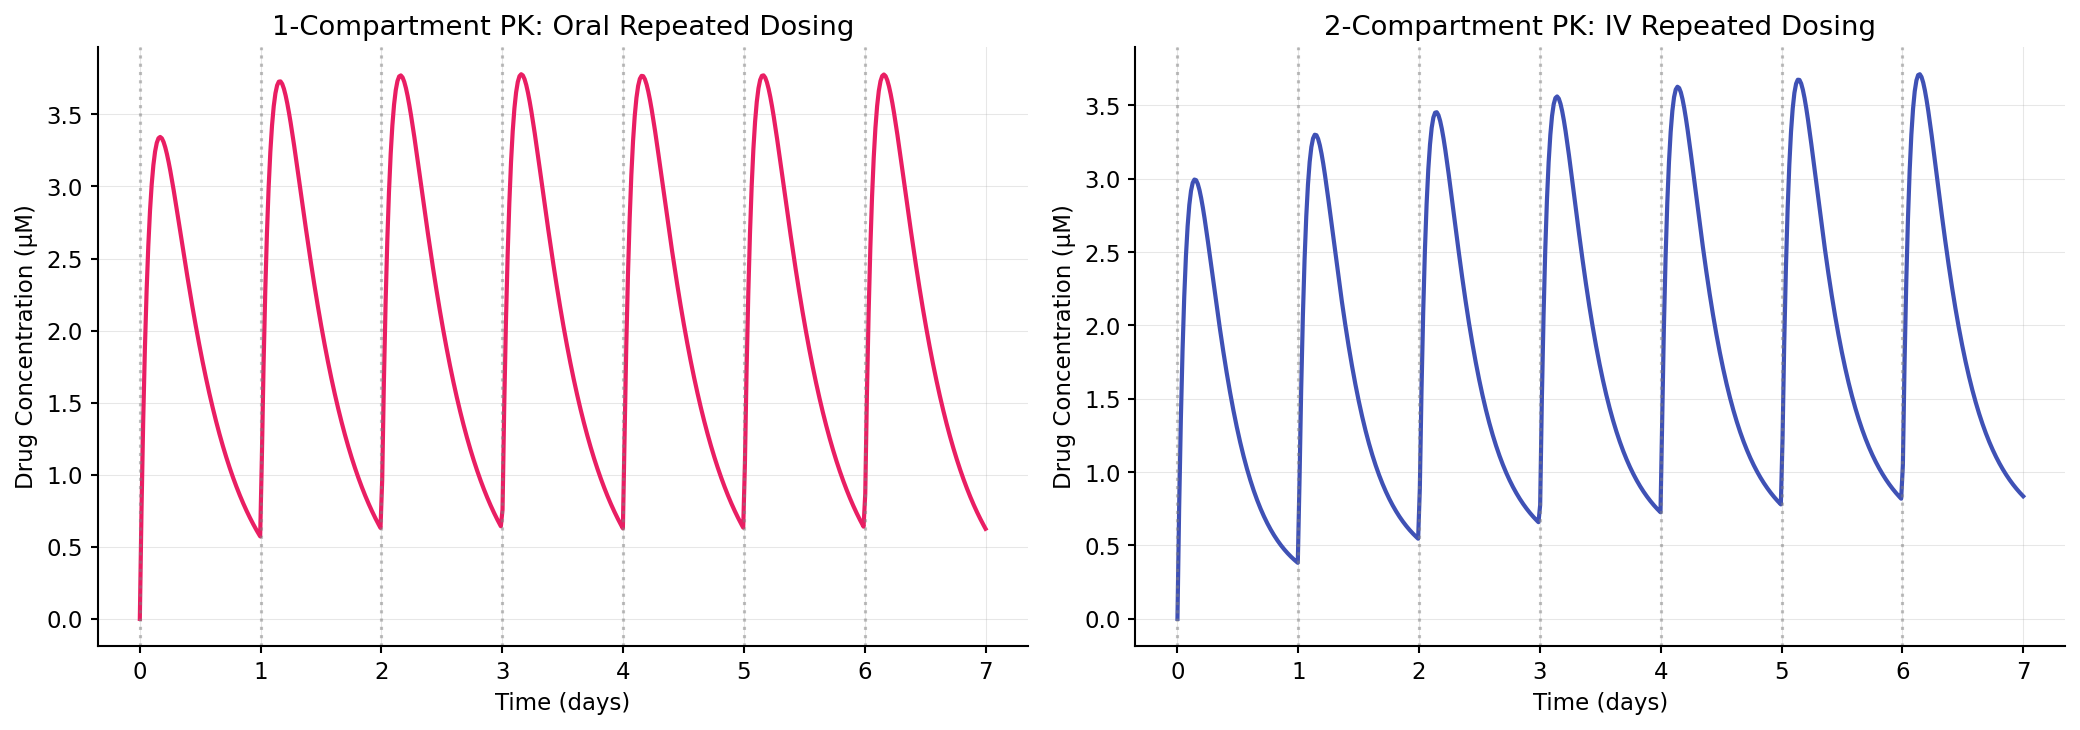

Key features:
  • Oral dosing: gradual absorption peak, then exponential decay
  • IV bolus: instant peak, bi-exponential decay (2-compartment)
  • Drug accumulates with repeated dosing until steady state


In [27]:
# --- Visualize PK profiles ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Drug concentration over time
axes[0].plot(t_pk / 24, conc_profile, color="#E91E63", linewidth=2)
for d in dosing.doses:
    axes[0].axvline(d.time / 24, color="gray", linestyle=":", alpha=0.5)
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Drug Concentration (µM)")
axes[0].set_title("1-Compartment PK: Oral Repeated Dosing")

# Right: 2-compartment for comparison
pk_2comp = TwoCompartmentPK(
    vc=10.0, vp=20.0, cl=1.0, q=0.5, ka=0.5
)
dosing_iv = DosingSchedule.repeated(
    dose_amount=50.0, interval=24.0, n_doses=7, route="iv_bolus"
)
conc_2comp = pk_2comp.solve(dosing_iv, t_pk)

axes[1].plot(t_pk / 24, conc_2comp, color="#3F51B5", linewidth=2)
for d in dosing_iv.doses:
    axes[1].axvline(d.time / 24, color="gray", linestyle=":", alpha=0.5)
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Drug Concentration (µM)")
axes[1].set_title("2-Compartment PK: IV Repeated Dosing")

plt.tight_layout()
plt.show()

print("Key features:")
print("  • Oral dosing: gradual absorption peak, then exponential decay")
print("  • IV bolus: instant peak, bi-exponential decay (2-compartment)")
print("  • Drug accumulates with repeated dosing until steady state")

Luciferin peak time: 5.1 min post-injection
Optimal imaging window (≥90% peak): 1.8 – 13.5 min


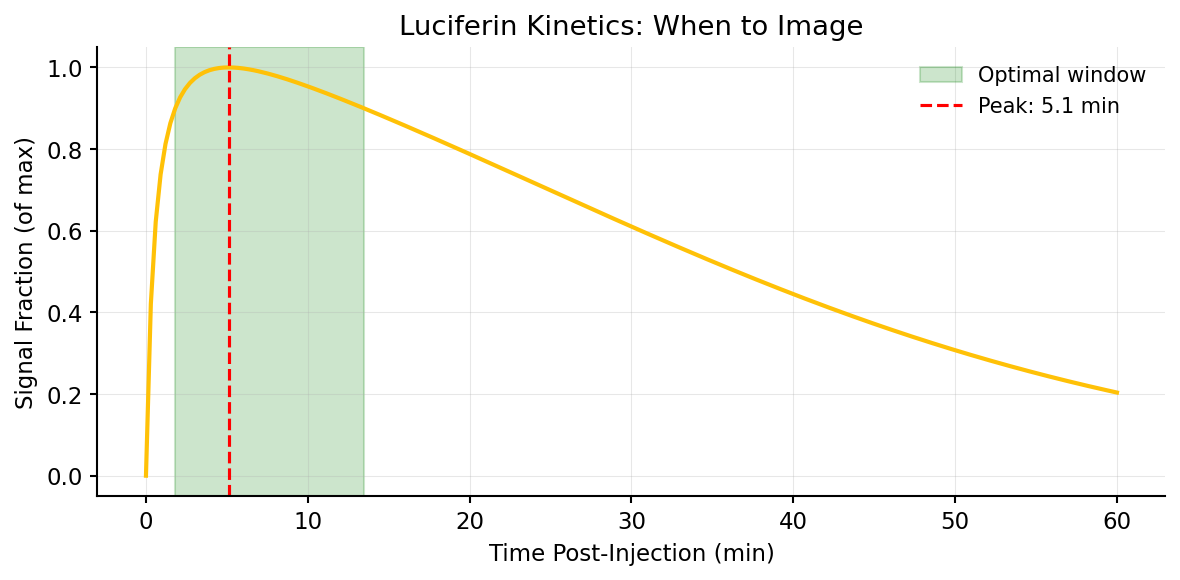

In [28]:
# --- BLI with Luciferin Kinetics ---
# In vivo BLI requires modeling luciferin substrate availability

luciferin = LuciferinKinetics(
    dose=150.0,     # mg/kg luciferin injected
    ka_luc=0.5,     # absorption rate (1/min)
    ke_luc=0.05,    # elimination rate (1/min)
    km=50.0         # Michaelis constant
)

print(f"Luciferin peak time: {luciferin.peak_time:.1f} min post-injection")
window = luciferin.optimal_imaging_window(tolerance=0.9)
print(f"Optimal imaging window (≥90% peak): {window[0]:.1f} – {window[1]:.1f} min")

# Plot luciferin signal over time
t_luc = np.linspace(0, 60, 200)
signal = [luciferin.signal_fraction(t) for t in t_luc]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_luc, signal, color="#FFC107", linewidth=2)
ax.axvspan(window[0], window[1], alpha=0.2, color="green", label="Optimal window")
ax.axvline(luciferin.peak_time, color="red", linestyle="--", label=f"Peak: {luciferin.peak_time:.1f} min")
ax.set_xlabel("Time Post-Injection (min)")
ax.set_ylabel("Signal Fraction (of max)")
ax.set_title("Luciferin Kinetics: When to Image")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

**Pharmacokinetics** bridge the gap between drug dosing and tumor exposure:

| Model | Use Case | Key Parameters |
|-------|----------|----------------|
| Constant | In vitro plates | concentration (µM) |
| 1-Compartment | Simple in vivo | Vd, ke, (ka for oral) |
| 2-Compartment | Complex in vivo | Vc, Vp, CL, Q |

**Luciferin kinetics** are critical for BLI — imaging at the wrong time gives misleading signal changes that look like biological effects but are really substrate kinetics.

---
## 13. Transfer Learning: In Vitro → In Vivo

A powerful U-MIMIC feature: use well-characterized **in vitro** parameter estimates as **informative priors** for data-scarce **in vivo** experiments.

In [29]:
# --- Step 1: We already have in vitro MCMC results from Section 11 ---
# Package them as an InferenceResult
invitro_result = InferenceResult(
    method="mcmc",
    mcmc=mcmc_result,
    context="in_vitro",
    metadata={"drug": "Doxorubicin", "cell_line": "MCF7"}
)

print("=== In Vitro Result ===")
print(f"Method: {invitro_result.method}")
print(f"Context: {invitro_result.context}")
print(f"Point estimates: {invitro_result.point_estimates}")

# --- Step 2: Build transfer learning ---
transfer = TransferLearning(
    invitro_result=invitro_result,
    transfer_params=["b0", "d0_P", "emax_death", "ec50_death"],  # which params to transfer
    shrinkage=1.0   # 1.0 = use posterior directly; >1 = inflate uncertainty
)

# Build informative priors from in vitro posteriors
invivo_priors = transfer.build_priors()

print("\n=== Transfer Learning ===")
print(f"Transferred parameters: {transfer.transfer_params}")
summary = transfer.summarize_transfer()
print(f"\nIn vitro → In vivo prior mapping:")
for key, val in summary.items():
    print(f"  {key}: {val}")

=== In Vitro Result ===
Method: mcmc
Context: in_vitro
Point estimates: {'b0': 0.021794355902622763, 'd0_P': 0.0139050344503488, 'emax_death': 0.07362910707234901, 'ec50_death': 3.2452500442416317, 'hill_death': 1.5043846953871596, 'u_PQ': 0.006758017910107747, 'u_QP': 0.0038472982680627264, 'overdispersion': 11.531080220369528}

=== Transfer Learning ===
Transferred parameters: ['b0', 'd0_P', 'emax_death', 'ec50_death']

In vitro → In vivo prior mapping:
  n_params_transferred: 4
  shrinkage: 1.0
  parameters: {'b0': {'prior_mean': 0.021822543217365407, 'prior_std': 0.007700719781879639, 'prior_type': 'lognormal'}, 'd0_P': {'prior_mean': 0.014081139356838638, 'prior_std': 0.008157184877574436, 'prior_type': 'lognormal'}, 'emax_death': {'prior_mean': 0.08609821039439067, 'prior_std': 0.1200420555529134, 'prior_type': 'lognormal'}, 'ec50_death': {'prior_mean': 3.3536798230244433, 'prior_std': 3.7747936551302845, 'prior_type': 'lognormal'}}


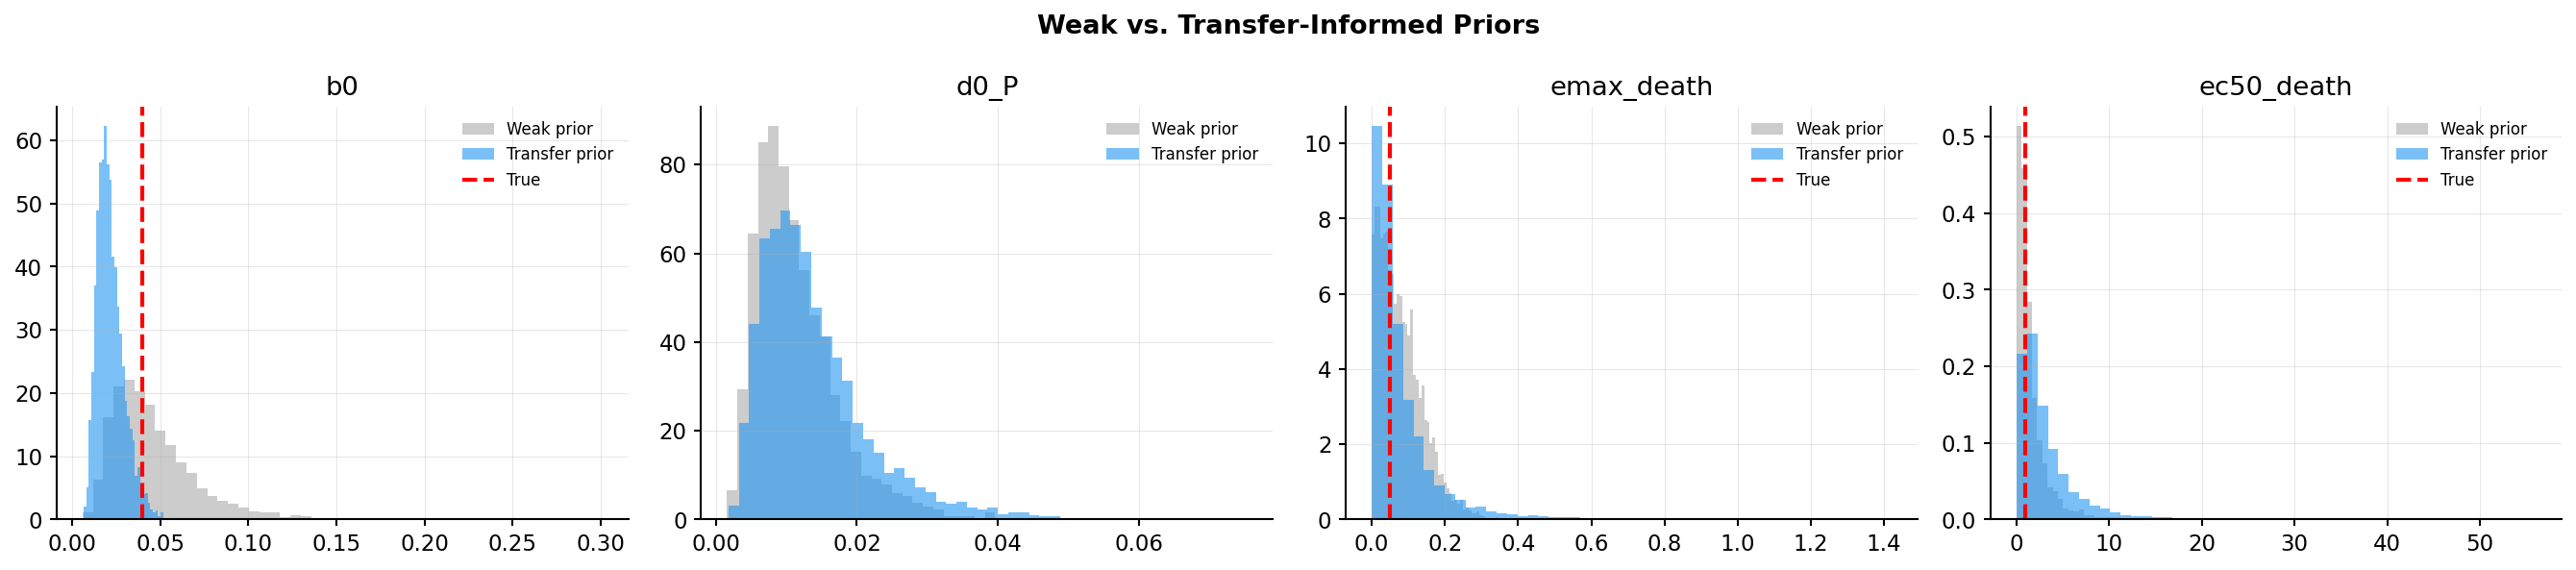

Transfer learning benefits:
  • In vitro experiments are cheap and well-controlled
  • In vivo experiments have few animals and sparse measurements
  • Transfer priors 'borrow strength' from in vitro to improve in vivo inference
  • The shrinkage factor controls how much to trust in vitro estimates


In [30]:
# --- Step 3: Compare priors ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

weak_priors = PriorSpec.default_invitro()
params_to_show = ["b0", "d0_P", "emax_death", "ec50_death"]

for i, param in enumerate(params_to_show):
    ax = axes[i]
    
    # Weak prior (default)
    if param in weak_priors.distributions:
        x_weak = [weak_priors.distributions[param].rvs() for _ in range(5000)]
        ax.hist(x_weak, bins=50, density=True, alpha=0.4, color="gray", label="Weak prior")
    
    # Informative prior (from transfer)
    if param in invivo_priors.distributions:
        x_info = [invivo_priors.distributions[param].rvs() for _ in range(5000)]
        ax.hist(x_info, bins=50, density=True, alpha=0.6, color="#2196F3", label="Transfer prior")
    
    # True value
    true_val = TRUE_PARAMS.get(param)
    if true_val:
        ax.axvline(true_val, color="red", linestyle="--", linewidth=2, label="True")
    
    ax.set_title(param)
    ax.legend(fontsize=8)

fig.suptitle("Weak vs. Transfer-Informed Priors", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Transfer learning benefits:")
print("  • In vitro experiments are cheap and well-controlled")
print("  • In vivo experiments have few animals and sparse measurements")
print("  • Transfer priors 'borrow strength' from in vitro to improve in vivo inference")
print("  • The shrinkage factor controls how much to trust in vitro estimates")

---
## 14. High-Level Pipeline: YAML Configuration

For production use, U-MIMIC provides a **configuration-driven pipeline** that handles everything through a single YAML file.

In [31]:
# --- Build configuration programmatically ---
config = ExperimentConfig(
    name="tutorial_experiment",
    context="in_vitro",
    dynamics={"states": ["P", "Q"], "density_dependent": False},
    dosing={"type": "constant", "concentrations": [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]},
    observations={"modalities": ["cell_counts"], "cell_count_overdispersion": 10.0},
    inference={"mode": "mle", "backend": "scipy", "n_restarts": 5},
    simulation={"method": "gillespie", "initial_cells": 100, "t_max": 72.0,
                "dt_obs": 4.0, "n_replicates": 4, "seed": 42}
)

print("=== ExperimentConfig ===")
print(f"Name: {config.name}")
print(f"Context: {config.context}")
print(f"States: {config.dynamics.states}")
print(f"Dosing type: {config.dosing.type}")
print(f"Concentrations: {config.dosing.concentrations}")
print(f"Observation modalities: {config.observations.modalities}")
print(f"Inference mode: {config.inference.mode}")
print(f"Simulation method: {config.simulation.method}")

=== ExperimentConfig ===
Name: tutorial_experiment
Context: in_vitro
States: ['P', 'Q']
Dosing type: constant
Concentrations: [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
Observation modalities: ['cell_counts']
Inference mode: mle
Simulation method: gillespie


In [32]:
# --- The equivalent YAML file would look like this: ---
yaml_content = """
# ============================================
# U-MIMIC Experiment Configuration
# ============================================

name: tutorial_experiment
context: in_vitro
seed: 42

dynamics:
  states: [P, Q]
  density_dependent: false

dosing:
  type: constant
  concentrations: [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]

observations:
  modalities: [cell_counts]
  cell_count_overdispersion: 10.0

inference:
  mode: mle
  backend: scipy
  n_restarts: 5

simulation:
  method: gillespie
  initial_cells: 100
  t_max: 72.0
  dt_obs: 4.0
  n_replicates: 4

# For MCMC, change inference to:
# inference:
#   mode: mcmc
#   backend: emcee
#   n_samples: 2000
#   n_chains: 4
#   n_warmup: 1000
"""

print(yaml_content)


# ============================================
# U-MIMIC Experiment Configuration
# ============================================

name: tutorial_experiment
context: in_vitro
seed: 42

dynamics:
  states: [P, Q]
  density_dependent: false

dosing:
  type: constant
  concentrations: [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]

observations:
  modalities: [cell_counts]
  cell_count_overdispersion: 10.0

inference:
  mode: mle
  backend: scipy
  n_restarts: 5

simulation:
  method: gillespie
  initial_cells: 100
  t_max: 72.0
  dt_obs: 4.0
  n_replicates: 4

# For MCMC, change inference to:
# inference:
#   mode: mcmc
#   backend: emcee
#   n_samples: 2000
#   n_chains: 4
#   n_warmup: 1000



In [33]:
# --- Use the Experiment class (high-level orchestrator) ---
experiment = Experiment(config)

print("=== Experiment Object ===")
print(f"Topology: {[s.value for s in experiment.topology.active_states]}")
print(f"Rate set birth rate: {experiment.rate_set.birth_base}")
print()

# Simulate
sim_results = experiment.simulate(
    concentrations=[0.0, 1.0, 5.0]
)

print("Simulation results:")
for conc, result in sim_results.items():
    print(f"  {conc} µM: {result.viable[0]:.0f} → {result.viable[-1]:.0f} cells "
          f"over {result.times[-1]:.0f}h")

# Generate synthetic data
synth = experiment.generate_synthetic()
print(f"\nGenerated synthetic dataset: {synth.n_series} series")

print("\n" + "="*50)
print("CLI equivalent commands:")
print("  umimic simulate --config config.yaml")
print("  umimic generate --config config.yaml")
print("  umimic fit --config config.yaml --data data.csv")
print("  umimic dashboard")

=== Experiment Object ===
Topology: ['proliferating', 'quiescent']
Rate set birth rate: 0.04

Simulation results:
  0.0 µM: 100 → 701 cells over 72h
  1.0 µM: 100 → 701 cells over 72h
  5.0 µM: 100 → 701 cells over 72h

Generated synthetic dataset: 24 series

CLI equivalent commands:
  umimic simulate --config config.yaml
  umimic generate --config config.yaml
  umimic fit --config config.yaml --data data.csv
  umimic dashboard


---
## 15. Summary & Next Steps

### What We Covered

| Section | Key Concept |
|---------|-------------|
| Cell States | P (proliferating), Q (quiescent), A (apoptotic), R (resistant) |
| Dose-Response | EmaxHill equation; cytotoxic vs. cytostatic mechanisms |
| ODE Simulation | Deterministic mean-field dynamics |
| Gillespie SSA | Exact stochastic simulation; individual-level noise |
| Moment Equations | LNA: mean + variance in one solve; mechanistic variance signature |
| Observations | Cell counts (NegBin), BLI (LogNormal), Volume, Ki-67 (Beta) |
| Data Structures | TimeSeriesData (one replicate) → ExperimentalDataset (full experiment) |
| Synthetic Data | Generate realistic test datasets for validation |
| MLE | Fast point estimates with AIC/BIC for model comparison |
| MCMC | Full posterior distributions with convergence diagnostics |
| Pharmacokinetics | 1/2-compartment PK; dosing schedules; luciferin kinetics |
| Transfer Learning | In vitro posteriors → in vivo priors |
| Pipeline | YAML-driven configuration; CLI commands |

### Typical Workflow

```
1. Design experiment       → Choose topology, dosing, observation modalities
2. (Optional) Power analysis → Generate synthetic data, check identifiability
3. Collect data            → Format as CSV (hours, count, concentration, replicate)
4. Load data               → load_csv() → ExperimentalDataset
5. Run MLE                 → Quick parameter estimates, model comparison (AIC/BIC)
6. Run MCMC                → Full uncertainty quantification
7. Diagnose                → R-hat, ESS, trace plots, posterior predictive checks
8. (Optional) Transfer     → Use in vitro results as priors for in vivo
9. Report                  → Posterior summaries, credible intervals, visualizations
```

### Key Tips

- **Start simple**: 2-state topology, MLE, single modality. Add complexity only when data supports it.
- **Always validate**: Use synthetic data to check parameter recovery before fitting real data.
- **Check diagnostics**: R-hat, ESS, and trace plots are essential for MCMC.
- **Use variance**: The LNA variance signature can distinguish drug mechanisms — this is unique to U-MIMIC.
- **Transfer wisely**: Set shrinkage > 1 if in vitro conditions differ substantially from in vivo.